# **Packinghouse and Transport Chain Assessment of the Effect of Hot Water Treatment (HWT) and Season on Physiological and Pathological Loss of Carabao Mango (*Mangifera indica*), 2023–2024**

## Problem Statement: 
Carabao mango is a high-value fruit in the Philippines, available year-round because of flower induction. Its supply, price, and quality still change with the season: wet-season fruit is scarcer, more expensive, and more exposed to anthracnose and stem-end rot. Hot water treatment (HWT) is a low-cost protocol for reducing postharvest loss, but its effect on physiological and pathological loss along the packinghouse and transport chain, across seasons and years, still needs to be measured.

### Question:
Does the implementation of the hot water treatment (HWT) protocol result in the reduction of physiological loss and pathological loss in the packinghouse and transport chain node of Carabao mango?

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sps
from scipy import stats


In [2]:
# Importing Data Sets
mango2023 = pd.read_csv('mango_loss_2023.csv')
mango2024 = pd.read_csv('mango_loss_2024.csv')

In [3]:
# Initial Look of 2023 data set

shape = mango2023.shape
columns = mango2023.columns
describe = mango2023.describe()
info = mango2023.info()

print(shape, columns, describe)
print('\n')
print(info)

# Note:
    # 49 rows with three columns containing null values
        # This null values however is the result of not applying the hot water treatment
            # This is for hwt_temp_c and hwt_duration_min columns
            # This explains why value does not exist
            # For ambient_rh_pct
                # Needs to be investigated
    # date column is classified as str need to be converted into datetime data type

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   observation_id          48 non-null     int64  
 1   batch_id                48 non-null     str    
 2   date                    48 non-null     str    
 3   province                48 non-null     str    
 4   season                  48 non-null     str    
 5   chain_node              48 non-null     str    
 6   cultivar                48 non-null     str    
 7   hot_water_treated       48 non-null     str    
 8   hwt_temp_c              8 non-null      float64
 9   hwt_duration_min        8 non-null      float64
 10  dwell_time_hrs          48 non-null     float64
 11  starting_wt_kg          48 non-null     float64
 12  ending_wt_kg            48 non-null     float64
 13  loss_physiological_pct  48 non-null     float64
 14  loss_pathological_pct   48 non-null     float64
 15  am

In [4]:
# Initial Look of 2024 data set

shape = mango2024.shape
columns = mango2024.columns
describe = mango2024.describe()
info = mango2024.info()

print(shape, columns, describe)
print('\n')
print(info)

# Note:
    # Has more rows than 2023 data, need to see why
    # There is still null values - again some still did not utilized hot water treatment
        # date column is classified as str need to be converted into datetime data type

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   observation_id          49 non-null     int64  
 1   batch_id                49 non-null     str    
 2   date                    49 non-null     str    
 3   province                49 non-null     str    
 4   season                  49 non-null     str    
 5   chain_node              49 non-null     str    
 6   cultivar                49 non-null     str    
 7   hot_water_treated       49 non-null     str    
 8   hwt_temp_c              24 non-null     float64
 9   hwt_duration_min        24 non-null     float64
 10  dwell_time_hrs          49 non-null     float64
 11  starting_wt_kg          49 non-null     float64
 12  ending_wt_kg            49 non-null     float64
 13  loss_physiological_pct  49 non-null     float64
 14  loss_pathological_pct   49 non-null     float64
 15  am

In [5]:
# Checking date column data type to double check

print(mango2023['date'].dtypes)
print('\n')
print(mango2024['date'].dtypes)

str


str


In [6]:
# Conversion to str to datetime dtype for 'date' column

mango2023['date'] = pd.to_datetime(mango2023['date'])
mango2024['date'] = pd.to_datetime(mango2024['date'])

# Creating a year and month column
mango2023['year'] = mango2023['date'].dt.year
mango2023['month'] = mango2023['date'].dt.month

mango2024['year'] = mango2024['date'].dt.year
mango2024['month'] = mango2024['date'].dt.month


In [7]:
# Combining the two df into one

mango = pd.concat([mango2023, mango2024], ignore_index = True)

In [ ]:
# Observing the new df

shape = mango.shape
columns = mango.columns
describe = mango.describe()
info = mango.info()

print(shape, columns, describe)
print('/n')
print(info)

# 48 from mango2023 and 49 from mango2024 = 97 entries
# hwt t and duration still have null values as expected
    # 8 non-null values from mango2023 and 24 non-null values from mango2024 to the total of 32 non-null values
# for ambient rh pct another column that contains null values
    # 46 non-null frm 2023 and 46 non-null in 2024 tot tha total of 92
# Note:
    # From the previews df, in 2023 the max value does not add up for starting and end weight
        # Same was observed in 2024 data and this combined data

<class 'pandas.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   observation_id          97 non-null     int64         
 1   batch_id                97 non-null     str           
 2   date                    97 non-null     datetime64[us]
 3   province                97 non-null     str           
 4   season                  97 non-null     str           
 5   chain_node              97 non-null     str           
 6   cultivar                97 non-null     str           
 7   hot_water_treated       97 non-null     str           
 8   hwt_temp_c              32 non-null     float64       
 9   hwt_duration_min        32 non-null     float64       
 10  dwell_time_hrs          97 non-null     float64       
 11  starting_wt_kg          97 non-null     float64       
 12  ending_wt_kg            97 non-null     float64       
 13  los

In [9]:
# Weight anomaly

mango[mango['ending_wt_kg'] > mango['starting_wt_kg']]

# From this we are observing three observation_id that does not follow what should actually happening specially that there are loss pct

,observation_id,batch_id,date,province,season,chain_node,cultivar,hot_water_treated,hwt_temp_c,hwt_duration_min,dwell_time_hrs,starting_wt_kg,ending_wt_kg,loss_physiological_pct,loss_pathological_pct,ambient_temp_c,ambient_rh_pct,price_php_per_kg,year,month
12,1013,MB2023-007,2023-10-11,Pangasinan,Wet,packinghouse,Carabao,Yes,53.1,6.0,12.5,403.8,428.0,2.68,3.75,28.1,73.1,131.05,2023,10
28,1029,MB2023-015,2023-07-18,Zamboanga del Norte,Wet,packinghouse,Carabao,No,NaN,NaN,13.7,441.1,467.6,3.88,4.78,29.8,77.6,132.87,2023,7
68,2021,MB2024-011,2024-03-07,Zamboanga del Norte,Dry,packinghouse,Carabao,Yes,53.0,6.0,9.4,411.3,448.3,3.59,1.72,30.4,73.4,73.71,2024,3


In [10]:
# Dealing with anomalous weight data

# Making a copy df
mango_copy = mango[mango['ending_wt_kg'] > mango['starting_wt_kg']].copy()

# Computing actual loss
mango_copy['actual_loss'] = mango_copy['loss_physiological_pct'] + mango_copy['loss_pathological_pct']

# Swapping starting wt. with end wt. to get % loss if value would be the same as actual weight loss computed
mango_copy['pct_loss_swapped_values'] = 100 * ((mango_copy['ending_wt_kg'] - mango_copy['starting_wt_kg']) / mango_copy['ending_wt_kg'])

# Computing for implied loss in kg
mango_copy['implied_end_wt_kg'] = mango_copy['starting_wt_kg'] * (1 - mango_copy['actual_loss']/ 100)

# Observing values
mango_copy[['observation_id','batch_id','starting_wt_kg','ending_wt_kg',
     'actual_loss','pct_loss_swapped_values','implied_end_wt_kg']]

# Observation implies that the value was not simply swapped.
# actual_loss != pct_loss_swapped_values and ending_wt_kg != implied_end_wt_kg
    # implied_end_wt_kg is should be the value in the ending_wt_kg

,observation_id,batch_id,starting_wt_kg,ending_wt_kg,actual_loss,pct_loss_swapped_values,implied_end_wt_kg
12,1013,MB2023-007,403.8,428.0,6.43,5.654206,377.83566
28,1029,MB2023-015,441.1,467.6,8.66,5.667237,402.90074
68,2021,MB2024-011,411.3,448.3,5.31,8.253402,389.45997


In [11]:
# wt anomaly with batch id
mango[mango['batch_id'].isin(['MB2023-007','MB2023-015','MB2024-011'])][['batch_id','chain_node','starting_wt_kg','ending_wt_kg']].sort_values(['batch_id','chain_node'])

# Comparing values computed above, we can see that the ending_wt_kg values for packinghouse chain_node does not align with actual supposed values for the three observations
# Dropping the rows is not a viable route as it would result to remaining transport chain_node without a packinghouse chain_node 

,batch_id,chain_node,starting_wt_kg,ending_wt_kg
12,MB2023-007,packinghouse,403.8,428.0
13,MB2023-007,transport,377.8,352.0
28,MB2023-015,packinghouse,441.1,467.6
29,MB2023-015,transport,402.9,372.6
68,MB2024-011,packinghouse,411.3,448.3
69,MB2024-011,transport,389.5,381.3


In [ ]:
# Repairing the three rows

# Flag before repairing, so the correction is auditable
if 'wt_corrected' not in mango.columns:
    mango['wt_corrected'] = mango['ending_wt_kg'] > mango['starting_wt_kg']

# Repair only those rows, from the trusted loss columns
bad_mask = mango['wt_corrected']
mango.loc[bad_mask, 'ending_wt_kg'] = (
    mango.loc[bad_mask, 'starting_wt_kg'] *
    (1 - (mango.loc[bad_mask, 'loss_physiological_pct'] +
          mango.loc[bad_mask, 'loss_pathological_pct']) / 100)
).round(1)

# Verifying that the code run as intended
ver_1 = (mango['ending_wt_kg'] > mango['starting_wt_kg']).sum()
ver_2 = mango['wt_corrected'].sum()

print('rows still impossible:', ver_1)
print('rows corrected:', ver_2)

rows still impossible: 0
rows corrected: 3


In [13]:
# Checking checking corrected value
mango[mango['batch_id'].isin(['MB2023-007','MB2023-015','MB2024-011'])][['batch_id','chain_node','starting_wt_kg','ending_wt_kg']].sort_values(['batch_id','chain_node'])

,batch_id,chain_node,starting_wt_kg,ending_wt_kg
12,MB2023-007,packinghouse,403.8,377.8
13,MB2023-007,transport,377.8,352.0
28,MB2023-015,packinghouse,441.1,402.9
29,MB2023-015,transport,402.9,372.6
68,MB2024-011,packinghouse,411.3,389.5
69,MB2024-011,transport,389.5,381.3


In [ ]:
# Checking if the total % loss is the same when wt% loss is computed

def check_loss_identity(df, tol=0.02):
    wt_route = (df['starting_wt_kg'] - df['ending_wt_kg']) / df['starting_wt_kg'] * 100
    loss_route = df['loss_physiological_pct'] + df['loss_pathological_pct']
    diff = (wt_route - loss_route).abs()
    return diff.max(), (diff > tol).sum()

max_dev, n_fail = check_loss_identity(mango)
print('max deviation (pp):', round(max_dev, 4))
print('rows failing tolerance:', n_fail)

max deviation (pp): 0.0198
rows failing tolerance: 0


In [15]:
# Checking for duplicates in the df
mango[mango.duplicated(keep = False)]

# This is from 2024, which implies that the extra row observed previously in mango_2024 may be this data
    # since it is a duplicate it can be dropped

,observation_id,batch_id,date,province,season,chain_node,cultivar,hot_water_treated,hwt_temp_c,hwt_duration_min,...,starting_wt_kg,ending_wt_kg,loss_physiological_pct,loss_pathological_pct,ambient_temp_c,ambient_rh_pct,price_php_per_kg,year,month,wt_corrected
83,2036,MB2024-018,2024-03-23,Cebu,Dry,transport,Carabao,No,NaN,NaN,...,318.1,296.4,3.92,2.89,28.1,79.1,77.04,2024,3,False
84,2036,MB2024-018,2024-03-23,Cebu,Dry,transport,Carabao,No,NaN,NaN,...,318.1,296.4,3.92,2.89,28.1,79.1,77.04,2024,3,False


In [16]:
# Dropping duplicated row

mango = mango.drop_duplicates()

# Checking values
print('Shape: ', mango.shape)
print('observation_id unique:', mango['observation_id'].is_unique)

# From 97 there is only 96 rows because 1 row was dropped
# From 20 columns now there is 21 columns this is because a column was added when ending_wt_kg was corrected

Shape:  (96, 21)
observation_id unique: True


In [17]:
# Checking values of categorical columns part 1

province = mango['province'].value_counts()
season =  mango['season'].value_counts()
chain_node =  mango['chain_node'].value_counts()
cultivar = mango['cultivar'].value_counts()
hwt =  mango['hot_water_treated'].value_counts()

print(province, season, chain_node, cultivar, hwt)
# Results indicate that only province name has variety in spacing and capitalization
# As it has

province
Pangasinan             28
Zamboanga del Norte    28
Cebu                   25
cebu                    3
pangasinan              2
ZAMBOANGA DEL NORTE     2
Zamboanga Del norte     2
 Pangasinan             1
Cebu                    1
Pangasinan              1
cebu                    1
 Cebu                   1
CEBU                    1
Name: count, dtype: int64 season
Dry    48
Wet    48
Name: count, dtype: int64 chain_node
packinghouse    48
transport       48
Name: count, dtype: int64 cultivar
Carabao    96
Name: count, dtype: int64 hot_water_treated
No     64
Yes    32
Name: count, dtype: int64


In [18]:
# Checking values of categorical columns part 2

province = mango['province'].unique()
season =  mango['season'].unique()
chain_node =  mango['chain_node'].unique()
cultivar = mango['cultivar'].unique()
hwt =  mango['hot_water_treated'].unique()

print(province, season, chain_node, cultivar, hwt)
# Confirms the different values from values_count
# Province column appears to still the only column with issues

<ArrowStringArray>
[         'Pangasinan',          'pangasinan',         ' Pangasinan',
 'Zamboanga del Norte', 'ZAMBOANGA DEL NORTE', 'Zamboanga Del norte',
                'Cebu',                'cebu',               'Cebu ',
         'Pangasinan ',               'cebu ',               ' Cebu',
                'CEBU']
Length: 13, dtype: str <ArrowStringArray>
['Dry', 'Wet']
Length: 2, dtype: str <ArrowStringArray>
['packinghouse', 'transport']
Length: 2, dtype: str <ArrowStringArray>
['Carabao']
Length: 1, dtype: str <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


- There are 3 Province
    - Pangasinan
        - outputs = ['Pangasinan' (28), 'pangasinan' (2),'\Pangasinan' (1), 'Pangasinan/' (1)]
        - total count = 4 (32)
    - Zamboanga del Norte
        - outputs = ['Zamboanga del Norte' (28), 'ZAMBOANGA DEL NORTE' (2), 'Zamboanga Del norte' (2)]
        - total count = 3 (32)
    - Cebu
        - outputs = ['Cebu' (25), 'cebu' (3), 'Cebu/' (1),'cebu ' (1), '\Cebu' (1), 'CEBU' (1)]
        - total count = 6 (32)
    - grand total of 96

- General Shape of the experiment categorical data:
    - 2 years: 2023, 2024
    - 3 provinces: Pangasinan, Zamboanga del Norte, Cebu
    - 2 season: Dry, Wet
    - 2 chain nodes: packinghouse, transport
    - 1 cultivar: Carabao
    - 2 answer to hwt: Yes, No

96 rows
÷ 2 rows/batch   = 48 batches          ← leave row-space
÷ 2 years        = 24 batches/year     ← slice by year
÷ 3 provinces    =  8 batches/province/year   ← slice by province
× 2 rows/batch   = 16 rows/province/year      ← return to row-space


In [19]:
# Checking spread of the province naming data
mango.groupby('year')['province'].value_counts()

year  province           
2023  Pangasinan             14
      Zamboanga del Norte    14
      Cebu                   13
      cebu                    2
      pangasinan              1
       Pangasinan             1
      ZAMBOANGA DEL NORTE     1
      Zamboanga Del norte     1
      Cebu                    1
2024  Pangasinan             14
      Zamboanga del Norte    14
      Cebu                   12
      pangasinan              1
      Pangasinan              1
      Zamboanga Del norte     1
      ZAMBOANGA DEL NORTE     1
      cebu                    1
      cebu                    1
       Cebu                   1
      CEBU                    1
Name: count, dtype: int64

In [20]:
# Cleaning province column

# Map
province_map = {
    'pangasinan' : 'Pangasinan',
    'zamboanga del norte' : 'Zamboanga del Norte',
    'cebu' : 'Cebu'
}

# Correcting the values in province
mango['province_clean'] = mango['province'].str.strip().str.lower().map(province_map)
    # str.strip -> removes trailing and leading spaces
    # str.lower -> converts all letter into lower case
    # map -> looks the lower case value in the map and then swaps the left side value with the right side value


In [21]:
# Checking spread of the province naming data
mango.groupby('year')['province_clean'].value_counts()

year  province_clean     
2023  Pangasinan             16
      Zamboanga del Norte    16
      Cebu                   16
2024  Pangasinan             16
      Zamboanga del Norte    16
      Cebu                   16
Name: count, dtype: int64

In [22]:
# Checking the data
province_counts = mango['province_clean'].value_counts()
province_na = mango['province_clean'].isna().sum()

size_year_province = mango.groupby(['year', 'province_clean']).size()
size_year_province_season = mango.groupby(['year', 'province_clean', 'season']).size()

print(province_counts, '\n', 'province_na:', province_na, '\n', 'size_year_province:', '\n',  size_year_province, '\n', 'size_year_province_season:' '\n', size_year_province_season)

province_clean
Pangasinan             32
Zamboanga del Norte    32
Cebu                   32
Name: count, dtype: int64 
 province_na: 0 
 size_year_province: 
 year  province_clean     
2023  Cebu                   16
      Pangasinan             16
      Zamboanga del Norte    16
2024  Cebu                   16
      Pangasinan             16
      Zamboanga del Norte    16
dtype: int64 
 size_year_province_season:
 year  province_clean       season
2023  Cebu                 Dry       8
                           Wet       8
      Pangasinan           Dry       8
                           Wet       8
      Zamboanga del Norte  Dry       8
                           Wet       8
2024  Cebu                 Dry       8
                           Wet       8
      Pangasinan           Dry       8
                           Wet       8
      Zamboanga del Norte  Dry       8
                           Wet       8
dtype: int64


In [23]:
# Sanity check
    # mass balance checking - the derived loss versus reported loss columns must agree
    # accepted tolerance is 0.02pp
    # result is within acceptable value
check_loss_identity(mango)

(np.float64(0.019842931937179564), np.int64(0))

In [24]:
# Investigating the null values of ambient_rh_pct
    # This was flagged in the observation of the datasets even before concatenation

na_values = mango[pd.isna(mango[['ambient_rh_pct']]).any(axis=1)]

print(na_values)

# Five (5) rows of ambient_rh_pct is null values
    # Investigate the distribution of values to determine if the rows are to be dropped of values mean or mode values can be used in this instances

    observation_id    batch_id       date             province season  \
6             1007  MB2023-004 2023-01-05           Pangasinan    Dry   
31            1032  MB2023-016 2023-07-20  Zamboanga del Norte    Wet   
61            2014  MB2024-007 2024-08-08           Pangasinan    Wet   
87            2039  MB2024-020 2024-01-19                 Cebu    Dry   
94            2046  MB2024-023 2024-08-13                 Cebu    Wet   

      chain_node cultivar hot_water_treated  hwt_temp_c  hwt_duration_min  \
6   packinghouse  Carabao                No         NaN               NaN   
31     transport  Carabao                No         NaN               NaN   
61     transport  Carabao               Yes        52.3               7.0   
87  packinghouse  Carabao                No         NaN               NaN   
94     transport  Carabao               Yes        53.5               5.0   

    ...  ending_wt_kg  loss_physiological_pct  loss_pathological_pct  \
6   ...         283.9     

In [25]:
# Describing the ambient_rh_pct column

describe_rh = mango['ambient_rh_pct'].describe()
print(describe_rh)

count    91.000000
mean     78.620879
std       5.652286
min      68.000000
25%      74.050000
50%      78.900000
75%      83.350000
max      87.800000
Name: ambient_rh_pct, dtype: float64


In [26]:
# Checking if ambient_rh_pct values are imputed per batch or row

tempo_mango = mango.dropna(subset = ['ambient_rh_pct'])
grouping = tempo_mango.groupby('batch_id')['ambient_rh_pct'].agg(['nunique', 'count'])
counts = grouping[grouping['count'] == 2]['nunique'].value_counts()
print(counts)
# the answer 2 means that packinghouse and transport rh was read in those areas separately, it was not a one time rh reading.
    # the nunique counts how many unique values are present in the batch, so the counts portion show how many batch has 2 unique rh values
# 43 different reading with remaining 5 values out of 48 (grouped by batch id) being the null values

known_affected_rh = mango.loc[[6, 31, 61, 87, 94], 'batch_id']
mango[mango['batch_id'].isin(known_affected_rh)][['batch_id', 'chain_node', 'ambient_rh_pct', 'season', 'month']].sort_values(['batch_id', 'chain_node'])
#.loc with as list of known null rows and looks for their batch ids
# .isin() scans the rows and return the values with the batch ids
# then the filter was applied in the selected list, and those with the same batch id is returned not only those containing null values

# Flagging that packinghouse and transport have different values per batch
    # The table below is not enough to conclude that season affects rh but it also does not completely remove season as a factor for rh
        # specially when rh is the measure on water in the air

nunique
2    43
Name: count, dtype: int64


,batch_id,chain_node,ambient_rh_pct,season,month
6,MB2023-004,packinghouse,NaN,Dry,1
7,MB2023-004,transport,74.0,Dry,1
30,MB2023-016,packinghouse,84.3,Wet,7
31,MB2023-016,transport,NaN,Wet,7
60,MB2024-007,packinghouse,77.9,Wet,8
61,MB2024-007,transport,NaN,Wet,8
87,MB2024-020,packinghouse,NaN,Dry,1
88,MB2024-020,transport,82.2,Dry,1
93,MB2024-023,packinghouse,80.6,Wet,8
94,MB2024-023,transport,NaN,Wet,8


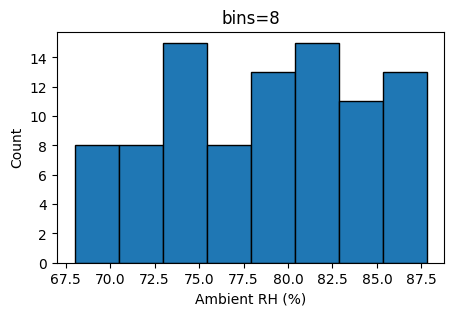

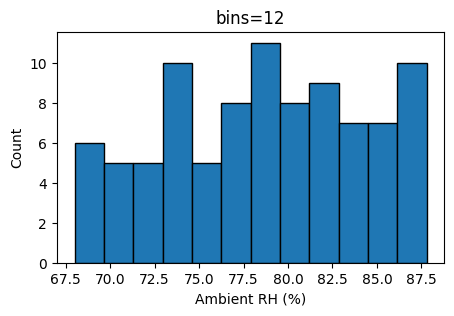

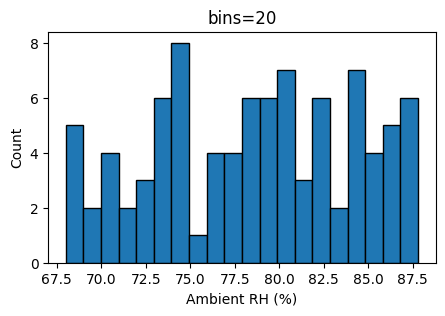

In [27]:
# Checking Distribution with Histogram with different bins
    # Using several bins to better check distribution

for b in [8, 12, 20]:
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(mango['ambient_rh_pct'].dropna(), bins=b, edgecolor='black')
    ax.set_xlabel('Ambient RH (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'bins={b}')
    plt.show()

# fig, ax with for loop was used to easily create three (3) histograms with different bin sizes
    # different bin sizes was used to account for:
        # few bins merge features
        # many bins can promote sampling noise
        # accounting for this similar features can be read as an observed trend
# Flag that for all bins next to 72-75 rh% or the 75-77rh% is a dip 
    # no conclusion can be made at this point
        # groupby below resolved why there is a dip, not due to binning and variables in the groupby.
        # Likely because of sampling

In [ ]:
# Checking possible effect of several variables to rh

for axis in ['season', 'month', 'chain_node', 'province_clean', 'year']:
    print(f'\n--- by {axis} ---')
    print(mango.groupby(axis)['ambient_rh_pct'].agg(['mean', 'std', 'min', 'max', 'count']))

# Observation on the data:
    # Season
        # There is not much of a difference in mean and std
    # Chain node
        # There is not much of a difference in mean and std
    # Province
        # There is not much of a difference in mean and std
        # But min of around 68 and max of around 87 is an interesting trend, but also point to the fact that there is no differences in rh per province
    # Year
        # There is not much of a difference in mean and std
    # Month
        # mean and std has a wider spread
            # however this is also affected by the amount of grouping (10 groups) and samples
            # mean rh is highest in Feb and lowest in June
            # According to PAGASA (2026), dry seasons are from Dec-May and wet season are from Jun-Nov
                # reference: PAGASA. (2026). Dost.Gov.Ph. https://www.pagasa.dost.gov.ph/information/climate-philippines
            # the highest and lowest rh mean per month does not follow the mechanism, wherein in wet season months rh should have been higher as there would be more water in the air

# The current observations show that for this dataset the listed variable does not show possible effect on the rh value


--- by season ---
             mean       std   min   max  count
season                                        
Dry     78.191304  5.782649  68.0  87.8     46
Wet     79.060000  5.546145  68.2  87.8     45

--- by month ---
            mean       std   min   max  count
month                                        
1      76.710000  4.313918  71.5  83.5     10
2      83.650000  3.116889  79.5  86.9      6
3      76.078571  6.405308  68.0  86.1     14
4      77.975000  5.487858  68.6  84.4     12
6      75.925000  2.828869  73.7  79.6      4
7      80.253846  5.711920  69.3  87.2     13
8      76.550000  4.683055  68.2  80.6      6
9      81.321429  5.952657  68.8  87.8     14
10     76.612500  4.666733  72.9  86.7      8
12     81.750000  6.044557  73.8  87.8      4

--- by chain_node ---
                   mean       std   min   max  count
chain_node                                          
packinghouse  79.354348  5.761239  68.0  87.5     46
transport     77.871111  5.501389  68.4  

                ambient_rh_pct  ambient_temp_c
ambient_rh_pct        1.000000        0.131075
ambient_temp_c        0.131075        1.000000


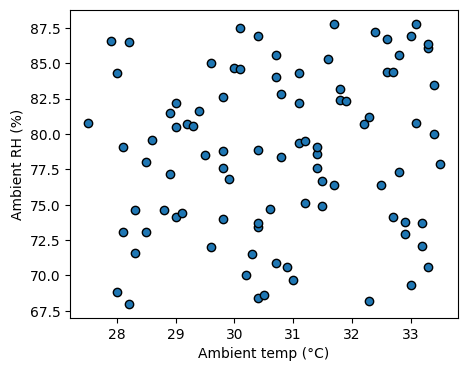

In [29]:
# Possible effect of Temperature on RH

pearson_corr = mango[['ambient_rh_pct', 'ambient_temp_c']].corr()
print(pearson_corr)
# Results indicate that there is no relationship between the two variables
# The scatter plot below also indicate the same relationship between the temp and rh.
    # the scatter plot is dispersed
    # this indicates that when Claude AI generated the data set, rh was independently generated and is not affected by any other factors in the dataset

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(mango['ambient_temp_c'], mango['ambient_rh_pct'], edgecolor='black')
ax.set_xlabel('Ambient temp (°C)'); ax.set_ylabel('Ambient RH (%)')
plt.show()

# no grouping affects the assigning of rh value
# The decision now relies on the histogram and .describe(): mean or median
    # mean: 78.620879, median(50%) = 78.900000, std = 5.652286
    # mean and median values are almost the same value
        # median is the robust choice since the data would not be affected by possible outlier


**Conclusion on how to fill missing RH% values**

Overall, RH is best estimated using the median of ambient_rh_pct column because no variable or group of variable was tested to affect the RH value. And median was chosen over near-identical mean as it is robust in the presence of outliers.

In [30]:
# Filling null values in ambient_rh_pct column

median_rh = mango['ambient_rh_pct'].median()
no_observation = mango['ambient_rh_pct'].notna().sum()
print(f'Fill value (median of {no_observation} observations): {median_rh}')

if 'rh_estimated' not in mango.columns:
    mango['rh_estimated'] = mango['ambient_rh_pct'].isna()

mango['ambient_rh_pct'] = mango['ambient_rh_pct'].fillna(median_rh)

Fill value (median of 91 observations): 78.9


In [31]:
# Checking if fillna took effect

print(mango['ambient_rh_pct'].isna().sum())  
print(mango['rh_estimated'].sum())                
print(mango.loc[mango['rh_estimated'], ['batch_id','chain_node','ambient_rh_pct']])
print(check_loss_identity(mango))  

# Comparison of std after and before filling na
print(f'SD after fill: {round(mango['ambient_rh_pct'].std(), 6)} (before: 5.652286)')

0
5
      batch_id    chain_node  ambient_rh_pct
6   MB2023-004  packinghouse            78.9
31  MB2023-016     transport            78.9
61  MB2024-007     transport            78.9
87  MB2024-020  packinghouse            78.9
94  MB2024-023     transport            78.9
(np.float64(0.019842931937179564), np.int64(0))
SD after fill: 5.501884 (before: 5.652286)


In [32]:
# Proof that treatment application is per batch not per row

constancy = mango.groupby('batch_id')['hot_water_treated'].agg(['nunique','count'])
print(constancy['count'].value_counts()) 
print(constancy['nunique'].max())
# Answer indicates that values per batch are the same
    # 'count' - that every batch holds 2 rows (packinghouse + transport)
    # 'nunique' - the 2 rows have the same hot_water_treated value  - this was used because temp and duration are numerical values. Also that there is no unique value in those 2 rows

# Dropping the duplicate batch in an object

batches = mango.drop_duplicates(subset='batch_id').copy()
print(batches.shape) 
# Correct shape, since it started with 96 rows and 23 columns, dropping duplicate rows ends-up with 48 rows


count
2    48
Name: count, dtype: int64
1
(48, 23)


In [33]:
# Adaption rate
batches['hwt_bool'] = batches['hot_water_treated'].eq('Yes')

summary = batches.groupby('year')['hwt_bool'].agg(
    n_batches='count'
    , n_treated='sum'
    , adoption_rate_pct='mean'
)

summary['adoption_rate_pct'] *= 100
print(summary)

# Shows that the number of batches balanced to 48 which is number of rows (24 per year)
    # Originally 96 rows with adoption rate or 16% (2023) and 50% (2024)
        # Resulted to the same percentage as the uncollapsed row-level frame


      n_batches  n_treated  adoption_rate_pct
year                                         
2023         24          4          16.666667
2024         24         12          50.000000


In [ ]:
# Chain of custody
# The code check if the starting weight at the transport level is equals the ending weight from the packinghouse
    # This is to describe the weight flow of the fruit through the chain nodes
    # tolerance is 0.05 because weight in kg is written with one decimal place. So half a recording unit
    # Its difference with the check_loss_identity is that this checks the continuity of weight values from packinghouse to transport. While check_loss_identity is the rows own values add up.

def check_chain_of_custody(df, tol=0.05):
    """Verify transport.starting_wt_kg == packinghouse.ending_wt_kg per batch.
    Returns (max_abs_deviation_kg, n_batches_failing, failing_batch_ids)."""
    wide = df.pivot(index='batch_id', columns='chain_node',
                    values=['starting_wt_kg', 'ending_wt_kg'])
    handoff = wide[('ending_wt_kg', 'packinghouse')]
    receipt = wide[('starting_wt_kg', 'transport')]
    dev = (receipt - handoff).abs()
    failing = dev[dev > tol]
    return dev.max(), len(failing), list(failing.index)

print(check_chain_of_custody(mango))
# Result shows zero deviation and no failing batches

(np.float64(0.0), 0, [])


In [35]:
# Assessment of effect of hot water treatment on loss (physiological and pathological) split by year
    # Descriptive of the group means per treatment per year
    # Count is batch has 2 rows (packinghouse + transport) - hot_water_treated is constant across both. Halve for batches: 8/40 -> 4/20
    # std is within-group spread not standard error
    # Split by year because increase in adoption from 4 (2023) to 12 (2024) batches

effect_of_trmt_on_loss_pct = mango.groupby(['year', 'hot_water_treated'])[['loss_physiological_pct', 'loss_pathological_pct']].agg(['mean', 'std', 'count']).round(2)

print(effect_of_trmt_on_loss_pct)


                       loss_physiological_pct              \
                                         mean   std count   
year hot_water_treated                                      
2023 No                                  3.79  0.52    40   
     Yes                                 2.52  0.38     8   
2024 No                                  3.93  0.49    24   
     Yes                                 2.55  0.55    24   

                       loss_pathological_pct              
                                        mean   std count  
year hot_water_treated                                    
2023 No                                 3.90  1.23    40  
     Yes                                2.51  1.48     8  
2024 No                                 3.93  1.37    24  
     Yes                                2.22  1.28    24  


In [ ]:
# Computing for the pooled std

def pooled_sd(n1, s1, n2, s2):
    """Pooled within-group SD.
    n are ROW counts (2 per batch) — descriptive effect size only.
    Item 5 rebuilds this on 24 batches/year."""
    return np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

# Long form: one row per year x treatment x loss type.
arm_stats = (mango
    .groupby(['year', 'hot_water_treated'])[
        ['loss_physiological_pct', 'loss_pathological_pct']]
    .agg(['mean', 'std', 'count'])
    .stack(level=0, future_stack=True)
    .rename_axis(index=['year', 'hot_water_treated', 'loss_type'])
    .unstack('hot_water_treated'))

gaps = pd.DataFrame({
    'untreated_mean': arm_stats[('mean', 'No')],
    'treated_mean':   arm_stats[('mean', 'Yes')],
})
gaps['gap_pp']    = gaps['untreated_mean'] - gaps['treated_mean']
gaps['pooled_sd'] = pooled_sd(arm_stats[('count', 'No')],  arm_stats[('std', 'No')],
                              arm_stats[('count', 'Yes')], arm_stats[('std', 'Yes')])
gaps['gap_sd']    = gaps['gap_pp'] / gaps['pooled_sd']

# Sanity: gap_pp must read 1.27 / 1.38 (phys) and 1.39 / 1.70 (path) — known from the means.
print(gaps.round(3))

# Treated batches show lower loss than untreated
        # mean +- pooled std
    # In 2023: 
        # Physiological loss: untreated are between 3.3 and 4.3 while treated are between 2.1 and 2.9
            # loss has almost no possible overlap
        # Pathological loss: untreated are between 2.6 and 5.2 while treated are between 1.23 and 3.8
            # loss overlaps much more
        # For 2023 pathological % loss reduction is higher but also less reliable because of the overlap in values of treated and untreated
        # physiological % loss reduction is more reliable as there is not much overlap in values
    # In 2024
        # Physiological loss: untreated are between 3.4 and 4.4 while treated are between 2.0 and 3.1
            # loss has almost no possible overlap
        # Pathological loss: untreated are between 2.6 and 5.3 while treated are between 1.0 and 3.6
            # loss overlaps
        # Same observation as in 2023

                             untreated_mean  treated_mean  gap_pp  pooled_sd  \
year loss_type                                                                 
2023 loss_physiological_pct           3.791         2.524   1.268      0.499   
     loss_pathological_pct            3.903         2.508   1.395      1.270   
2024 loss_physiological_pct           3.928         2.551   1.377      0.521   
     loss_pathological_pct            3.927         2.225   1.702      1.326   

                             gap_sd  
year loss_type                       
2023 loss_physiological_pct   2.542  
     loss_pathological_pct    1.098  
2024 loss_physiological_pct   2.645  
     loss_pathological_pct    1.284  


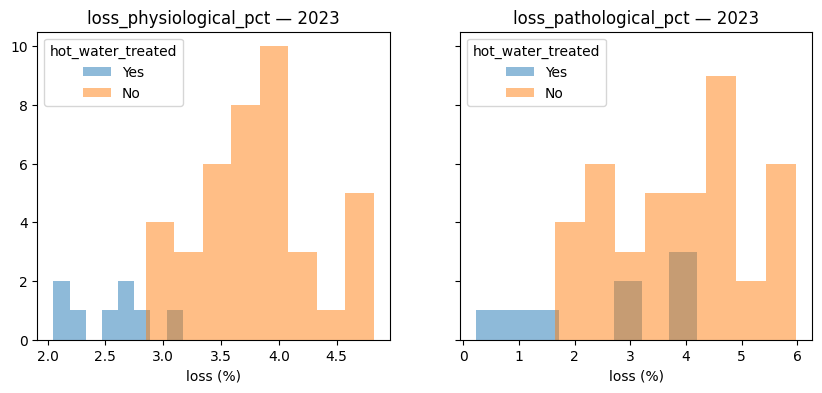

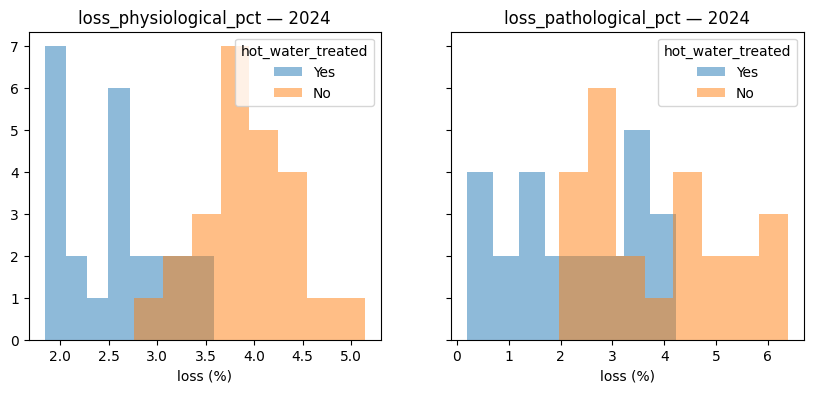

In [37]:
# Visualization of % loss
    # Code was provided by Claude AI

def plot_loss_by_group(df, year, group_col):
    """Overlaid histograms of both loss types, split by group_col, for one year."""
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    sub = df[df['year'] == year]
    for i, col in enumerate(['loss_physiological_pct', 'loss_pathological_pct']):
        for lvl in sub[group_col].unique():
            ax[i].hist(sub.loc[sub[group_col] == lvl, col],
                       bins=8, alpha=0.5, label=lvl)
        ax[i].set_title(f'{col} — {year}'); ax[i].set_xlabel('loss (%)')
        ax[i].legend(title=group_col)

hwt_styles = {'No':  dict(fill=False, edgecolor='black', linewidth=1.4),
              'Yes': dict(alpha=0.6, color='tab:orange')}

plot_loss_by_group(mango, 2023, 'hot_water_treated')
plot_loss_by_group(mango, 2024, 'hot_water_treated')

# Corroborates the interpretation of data above
    # Further illustrates the overlapping of values for pathological loss specially is 2024

## Expectation on the data
- Pathological loss is likelike to increase in Wet season there would an increase in rainfall, overcast days and higher RH which is an ideal environment for pathogens to grow. This may specifically lead to higher rates of antrachnose and stem-end rot which often remain latent until the fruit begins to ripen.
- Physiological loss is likely to increase in Dry season as high heat and low humidity accelerates the fruits respiration and transpiration rates. That cause rapid weight loss, shriveling and quicker softening. However the RH per season has been established in the difference in RH per year and season that there is not much difference in RH per season and is likely not going to affect the loss percentage.
- Wet season is likely to increase pathological loss and because of this it is expected to see less loss on treated samples than those untreated specially in the wet season months. I expect the season to show better separation.

In [38]:
# Distribution of treatment per season per year

batches = mango.drop_duplicates('batch_id')
trtm_blnc_seasons = pd.crosstab([batches['year'], batches['season']], batches['hot_water_treated'])

print(trtm_blnc_seasons)

hot_water_treated  No  Yes
year season               
2023 Dry           10    2
     Wet           10    2
2024 Dry            6    6
     Wet            6    6


In [39]:
# Difference in RH per year and season
mango.groupby(['year', 'season'])['ambient_rh_pct'].agg(['mean', 'std', 'count']).round(2)

# Wet season has a higher RH in both years but not by much. 
    # Not enough to argue that RH would affect % loss

mean   std  count
year season                    
2023 Dry     77.33  5.49     24
     Wet     78.88  5.52     24
2024 Dry     79.11  5.80     24
     Wet     79.22  5.32     24

In [40]:
# Assessment on effect of season on loss (physiological and pathological) split by year

effect_season_on_loss_pct = mango.groupby(['year', 'season'])[['loss_physiological_pct', 'loss_pathological_pct']].agg(['mean', 'std', 'count'])

print(effect_season_on_loss_pct)
# The data below shows that:
    # Physiological loss
        # Is not affected by season as there is not much difference between values
        # The std also reflects that the data point does not differ by much
    # Pathological loss
        # Although statistical test still needs to be run, the difference in loss per season is visually significant that we might be able to say that season affects this type of loss
        # The std per season and year only has a slight difference, so I am expecting data overlap

            loss_physiological_pct                 loss_pathological_pct  \
                              mean       std count                  mean   
year season                                                                
2023 Dry                  3.645000  0.746074    24              2.637917   
     Wet                  3.515000  0.630452    24              4.702500   
2024 Dry                  3.232083  0.929385    24              1.947083   
     Wet                  3.247500  0.817122    24              4.205000   

                             
                  std count  
year season                  
2023 Dry     0.978806    24  
     Wet     0.780887    24  
2024 Dry     1.034549    24  
     Wet     1.138603    24  


In [ ]:
# Computing for the pooled std

stats_season = (mango
    .groupby(['year', 'season'])[
        ['loss_physiological_pct', 'loss_pathological_pct']]
    .agg(['mean', 'std', 'count'])
    .stack(level=0, future_stack=True)
    .rename_axis(index=['year', 'season', 'loss_type'])
    .unstack('season'))

gaps_season = pd.DataFrame({
    'dry_mean': stats_season[('mean', 'Dry')],
    'wet_mean': stats_season[('mean', 'Wet')],
})
gaps_season['gap_pp'] = gaps_season['wet_mean'] - gaps_season['dry_mean']
gaps_season['pooled_sd'] = pooled_sd(stats_season[('count', 'Dry')], stats_season[('std', 'Dry')],
                                     stats_season[('count', 'Wet')], stats_season[('std', 'Wet')])
gaps_season['gap_sd'] = gaps_season['gap_pp'] / gaps_season['pooled_sd']
print(gaps_season.round(3))

# In 2023:
    # Physiological loss is between 3.0 and 4.3 in the dry season and between 2.8 and 4.2 in the wet season
        # The data indicates overlap between seasons for this type of loss
    # Pathological loss is 1.8 and 3.5 in the dry season and between 3.8 and 5.6 in the wet season
        # The data indicates that there is a small overlap in values between seasons for this type of loss
# In 2024
    # Physiological loss is between 2.6 and 4.1 in the dry season and between 2.3 and 4.1 in the wet season
        # The data indicates overlap between seasons for this type of loss
    # Pathological loss is 0.9 and 3.0 in the dry season and between 3.1 and 5.3 in the wet season
        # The data indicates that there is a small overlap in values between seasons for this type of loss

                             dry_mean  wet_mean  gap_pp  pooled_sd  gap_sd
year loss_type                                                            
2023 loss_physiological_pct     3.645     3.515  -0.130      0.691  -0.188
     loss_pathological_pct      2.638     4.702   2.065      0.885   2.332
2024 loss_physiological_pct     3.232     3.248   0.015      0.875   0.018
     loss_pathological_pct      1.947     4.205   2.258      1.088   2.076


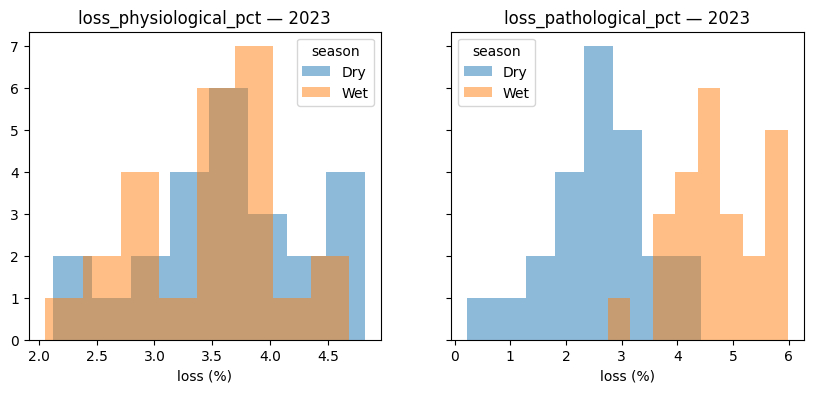

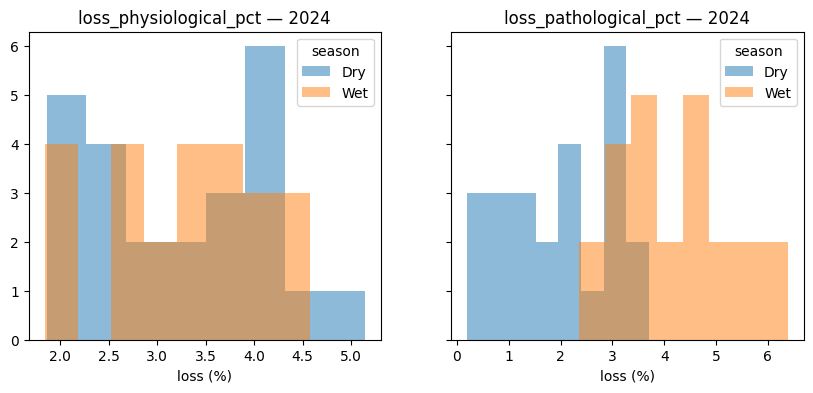

In [ ]:
# Visualization of % loss

season_styles = {'Dry': dict(fill=False, edgecolor='black', linewidth=1.4),
                 'Wet': dict(alpha=0.6, color='tab:orange')}

plot_loss_by_group(mango, 2023, 'season')
plot_loss_by_group(mango, 2024, 'season')

# The plots corroborate discussion above

## Adoption rate vs aggregate year-over-year change

| year | arm | n_batches | phys | path |
|---|---|---|---|---|
| 2023 | untreated | 20 | 3.79 | 3.90 |
| 2023 | treated   |  4 | 2.52 | 2.51 |
| 2024 | untreated | 12 | 3.93 | 3.93 |
| 2024 | treated   | 12 | 2.55 | 2.23 |

n = 24 (both years)
2023 treated samples = 4 batches

### Hand rehearsal 
ybar_year = (n_untr * ybar_untr + n_tr * ybar_tr) / (n_untr + n_tr)
Weights = adoption composition. Components = effects.
The aggregate has four inputs; it cannot by itself say which moved.

### Computation
2023 phys (20*3.79 + 4*2.52)/24 = 3.58

2023 path (20*3.90 + 4*2.51)/24 = 3.67

2024 phys (12*3.93 + 12*2.55)/24 = 3.24

2024 path (12*3.93 + 12*2.23)/24 = 3.08

Delta = 2024 - 2023.  phys -0.34, path -0.59.  Negative = loss fell.

### Adoption
- from 4/24 (2023) to 12/24 (2024)
- Treatment protocol did not changed only composition of samples



In [43]:
# Adoption rate, batch level
batches = mango.drop_duplicates('batch_id')
adoption = batches.groupby('year')['hot_water_treated'].value_counts(normalize=True).unstack()
print(adoption.round(3))

    # This code gives just returns the ratio on which treatment application was done in each year.
    # Basically the same as the 17% adoption in 2023 and 50% in 2024

# Aggregate — must match the hand rehearsal within rounding
print(mango.groupby('year')[['loss_physiological_pct','loss_pathological_pct']].mean().round(3))

    # Gets the average for both loss in each year

# Arm gaps — the discriminating statistic
arm = mango.groupby(['year','hot_water_treated'])[
    ['loss_physiological_pct','loss_pathological_pct']].mean().unstack('hot_water_treated')
gaps_year = (arm.xs('No', level='hot_water_treated', axis=1)
             - arm.xs('Yes', level='hot_water_treated', axis=1))
print(gaps_year.round(3))

    # Computes the gap between untreated and treated samples for each year

# Overall, loss percentage decreased in 2024 because more adopted the technology.

hot_water_treated     No    Yes
year                           
2023               0.833  0.167
2024               0.500  0.500
      loss_physiological_pct  loss_pathological_pct
year                                               
2023                    3.58                  3.670
2024                    3.24                  3.076
      loss_physiological_pct  loss_pathological_pct
year                                               
2023                   1.268                  1.395
2024                   1.377                  1.702


In [44]:
# Level diagnostics
    # To see if column changes within a batch

for col in ['province_clean', 'chain_node', 'dwell_time_hrs',
            'ambient_temp_c', 'ambient_rh_pct']:
    w_na  = mango.groupby('batch_id')[col].nunique(dropna=False).max()
    wo_na = mango.groupby('batch_id')[col].nunique(dropna=True).max()
    print(f'{col:20s} with NA: {w_na}   observed only: {wo_na}')

# Other than province, other variables vary across the nodes

province_clean       with NA: 1   observed only: 1
chain_node           with NA: 2   observed only: 2
dwell_time_hrs       with NA: 2   observed only: 2
ambient_temp_c       with NA: 2   observed only: 2
ambient_rh_pct       with NA: 2   observed only: 2


In [45]:
# Creating tabulation table of several variables

batches = mango.drop_duplicates('batch_id')

# Cross tabulation of province and if treated and one with year
print(pd.crosstab(batches['province_clean'], batches['hot_water_treated']))
print('\n')
print(pd.crosstab([batches['year'], batches['province_clean']], batches['hot_water_treated']))
print('\n')

# Cross tabulation of year and province with season
print(pd.crosstab([batches['year'], batches['province_clean']], batches['season']))

# The tables shows the distribution of treatment per variable


hot_water_treated    No  Yes
province_clean              
Cebu                 11    5
Pangasinan           10    6
Zamboanga del Norte  11    5


hot_water_treated         No  Yes
year province_clean              
2023 Cebu                  7    1
     Pangasinan            6    2
     Zamboanga del Norte   7    1
2024 Cebu                  4    4
     Pangasinan            4    4
     Zamboanga del Norte   4    4


season                    Dry  Wet
year province_clean               
2023 Cebu                   4    4
     Pangasinan             4    4
     Zamboanga del Norte    4    4
2024 Cebu                   4    4
     Pangasinan             4    4
     Zamboanga del Norte    4    4


In [46]:
# Row-level candidates: chain_node (categorical)
print(mango.groupby(['year','chain_node'])[['loss_physiological_pct','loss_pathological_pct']].agg(['mean','std','size']).round(3))

# For physiological loss in both years the amount of loss does not change much between chain nodes
# For pathological loss there is more difference but not by much.
    # There is possible overlap of data in loss % of chain nodes
print('\n')

# Batch-level: province
print(batches.groupby(['year','province_clean'])[['loss_physiological_pct','loss_pathological_pct']].agg(['mean','std','size']).round(3))

# There is a bit of difference in loss % per province per year but not by much.
# Also expected for values to overlap

print('\n')

# Continuous: correlation, not gap
for col in ['dwell_time_hrs','ambient_temp_c','ambient_rh_pct']:
    print(col, mango.groupby('year')[[col,'loss_physiological_pct',
          'loss_pathological_pct']].corr().round(3))

# The Pearson correlation data shows that there is no linear relationship across years, dwell time, ambient temperature and RH with either type of loss

print('\n')

# RH observed-only pass — the honest one
obs = mango[mango['ambient_rh_pct'].notna()]
print(obs)

                  loss_physiological_pct             loss_pathological_pct  \
                                    mean    std size                  mean   
year chain_node                                                              
2023 packinghouse                  3.602  0.697   24                 3.656   
     transport                     3.558  0.690   24                 3.685   
2024 packinghouse                  3.314  0.944   24                 3.214   
     transport                     3.165  0.793   24                 2.938   

                               
                     std size  
year chain_node                
2023 packinghouse  1.296   24  
     transport     1.454   24  
2024 packinghouse  1.784   24  
     transport     1.343   24  


                         loss_physiological_pct              \
                                           mean    std size   
year province_clean                                           
2023 Cebu                             

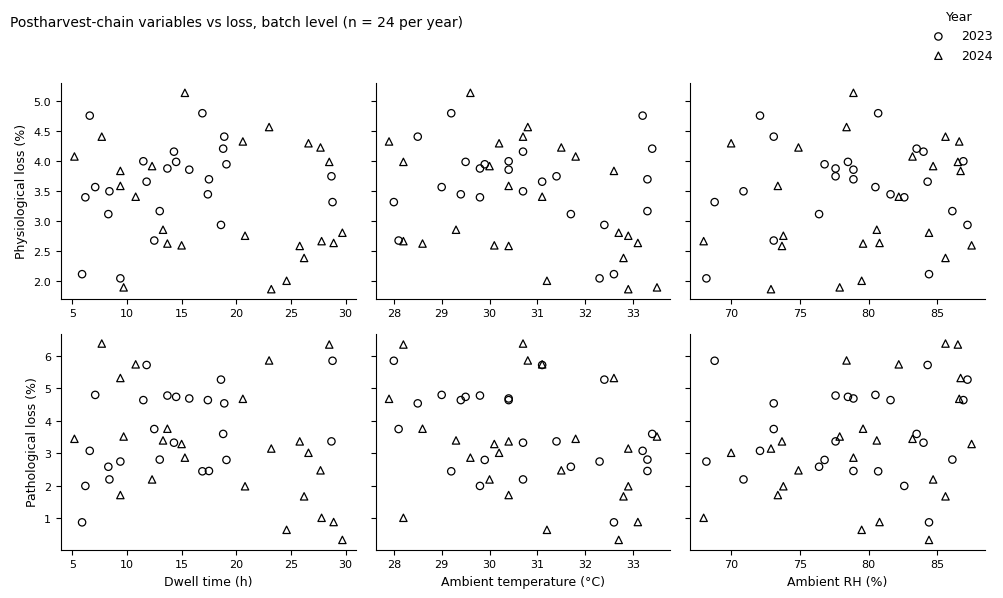

In [47]:
# Visualization of the Pearson correlation
    # To better support the data above

b = mango.drop_duplicates('batch_id')   # proxy collapse, exploratory only

x_labels = {'dwell_time_hrs':  'Dwell time (h)',
            'ambient_temp_c':  'Ambient temperature (°C)',
            'ambient_rh_pct':  'Ambient RH (%)'}
y_labels = {'loss_physiological_pct': 'Physiological loss (%)',
            'loss_pathological_pct':  'Pathological loss (%)'}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharey='row')

for j, col in enumerate(['dwell_time_hrs','ambient_temp_c','ambient_rh_pct']):
    for i, out in enumerate(['loss_physiological_pct','loss_pathological_pct']):
        ax = axes[i, j]
        for yr, mk in [(2023, 'o'), (2024, '^')]:
            d = b[b['year'] == yr]
            ax.scatter(d[col], d[out], marker=mk, facecolors='none',
                       edgecolors='black', s=28, linewidths=0.9,
                       label=str(yr) if (i == 0 and j == 0) else None)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=8)
        if i == 1:
            ax.set_xlabel(x_labels[col], fontsize=9)
        if j == 0:
            ax.set_ylabel(y_labels[out], fontsize=9)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=False,
           fontsize=9, title='Year', title_fontsize=9)

fig.suptitle('Postharvest-chain variables vs loss, batch level (n = 24 per year)',
             fontsize=10, x=0.01, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('fig_null_variables.svg', bbox_inches='tight')

In [48]:
# Collapse to one row per batch
        # The 96 node rows to 48 batch rows

# Creating a series of data with batch id and starting weight
        # Takes the information from the packinghouse
base = (mango[mango['chain_node'] == 'packinghouse'].set_index('batch_id')['starting_wt_kg'])
assert base.index.is_unique
assert set(base.index) == set(mango['batch_id'])

# Percentage loss to kg loss (Computation)
mango['phys_kg'] = mango['loss_physiological_pct'] / 100 * mango['starting_wt_kg']
mango['path_kg'] = mango['loss_pathological_pct']  / 100 * mango['starting_wt_kg']

# Adding up loss in kg then converting back to percentage
g = mango.groupby('batch_id')
phys_b = g['phys_kg'].sum() / base * 100
path_b = g['path_kg'].sum() / base * 100

# Checking if each column contains a single value across both rows
carry = ['year', 'province_clean', 'season', 'cultivar', 'hot_water_treated', 'hwt_temp_c', 'hwt_duration_min']
const = g[carry].nunique(dropna=False).max()
print(const)          # every entry must be 1
print('\n')

# Creating a new column for loss percentage
mango_batch = g[carry].first() # const above is the gate; .first() takes one value per batch and drops the other
mango_batch['loss_phys_batch_pct'] = phys_b
mango_batch['loss_path_batch_pct'] = path_b
mango_batch = mango_batch.reset_index()

# Same as first part but with transport chain node and then create a closure check
end_last = (mango[mango['chain_node'] == 'transport'].set_index('batch_id')['ending_wt_kg'])
total_obs = ((base - end_last) / base * 100)
resid = (total_obs - (phys_b + path_b)).abs()
print(resid.max())    # derive your own tolerance from the source decimals
print('\n')

# Checks if the shape of the df is correct
print(len(mango_batch), mango_batch['year'].value_counts().to_dict())

year                 1
province_clean       1
season               1
cultivar             1
hot_water_treated    1
hwt_temp_c           1
hwt_duration_min     1
dtype: int64


0.02946472019464963


48 {2023: 24, 2024: 24}


In [49]:
# Batch Price
    # The price_php_per_kg varies between the node rows
    # This code makes sure that the price is pulled from the packinghouse node 
        # The same node the mass base is from 

price_b = (mango[mango['chain_node'] == 'packinghouse'].set_index('batch_id')['price_php_per_kg'])

mango_batch['price_pkh_php_per_kg'] = mango_batch['batch_id'].map(price_b)
assert mango_batch['price_pkh_php_per_kg'].notna().all()

In [50]:
# Checking column values
print(mango.columns)
print(mango.shape)

Index(['observation_id', 'batch_id', 'date', 'province', 'season',
       'chain_node', 'cultivar', 'hot_water_treated', 'hwt_temp_c',
       'hwt_duration_min', 'dwell_time_hrs', 'starting_wt_kg', 'ending_wt_kg',
       'loss_physiological_pct', 'loss_pathological_pct', 'ambient_temp_c',
       'ambient_rh_pct', 'price_php_per_kg', 'year', 'month', 'wt_corrected',
       'province_clean', 'rh_estimated', 'phys_kg', 'path_kg'],
      dtype='str')
(96, 25)


In [51]:
# Dropping column 'province' since 'province_clean' contains the clean version
mango = mango.drop(columns='province', errors='ignore')
print(mango.columns)
print(mango.shape)

Index(['observation_id', 'batch_id', 'date', 'season', 'chain_node',
       'cultivar', 'hot_water_treated', 'hwt_temp_c', 'hwt_duration_min',
       'dwell_time_hrs', 'starting_wt_kg', 'ending_wt_kg',
       'loss_physiological_pct', 'loss_pathological_pct', 'ambient_temp_c',
       'ambient_rh_pct', 'price_php_per_kg', 'year', 'month', 'wt_corrected',
       'province_clean', 'rh_estimated', 'phys_kg', 'path_kg'],
      dtype='str')
(96, 24)


# Hypothesis
    # The SD of batches is likely yo be higher than SD of rows and ratio is less than 1.94
    # Out of the values determined to not have a linear relationship with loss, I think that even the highest value among them would stay under 0.3

# Result
    # SD_batch > SD_row and ratios < 1.94
    # ratio(s): 1.673 phys, 1.797 path
    # For province: 0.174 * 1.160 = 0.202 < 0.3
        # Other four not individually checked. Retirement bar is now explicit: anything retired under 0.259 (phys) / 0.278 (path) cannot cross 0.3 at the batch frame.

In [52]:
# Frame scaling, phys and path
results = {}
for row_col, batch_col in [('loss_physiological_pct', 'loss_phys_batch_pct'),
                           ('loss_pathological_pct',  'loss_path_batch_pct')]:
    sd_row     = mango[row_col].std()
    sd_batch   = mango_batch[batch_col].std()
    sd_bmean   = mango.groupby('batch_id')[row_col].mean().std()
    ratio      = sd_batch / sd_row
    inflation  = 1.94 / ratio
    results[row_col] = inflation
    print(f'{row_col:24} SD_row={sd_row:.4f}  SD_batch={sd_batch:.4f}  '
          f'ratio={ratio:.3f}  disagreement={sd_row/sd_bmean:.3f}  '
          f'inflation={inflation:.3f}')

# SD_batch > SD_row
# ratios < 1.94
# SD_batch / SD(per-batch node means) = 1.3311 / 0.7089 = 1.878
# SD_batch / SD(per-batch node means) recovers the frame multiplier
# directly (~1.88), confirming batch% ≈ 1.94 x mean row% empirically.


loss_physiological_pct   SD_row=0.7957  SD_batch=1.3311  ratio=1.673  disagreement=1.122  inflation=1.160
loss_pathological_pct    SD_row=1.4914  SD_batch=2.6795  ratio=1.797  disagreement=1.056  inflation=1.080


## Pre-step b — arm shape before `ttest_ind`

`ttest_ind` assumes approximate normality within each arm. 2023 splits
4 treated / 20 untreated; n=4 cannot be tested for normality (no power
to reject), so the four values are read directly instead.

# Hypothesis
    - The values of loss with treatment is like to be a tighter cluster in 2023 than in 2024
    - The batch-frame treatment gap likely stands around 2.4 

# Result
    - 2023 treatment batch value looks like a tight cluster but n = 4 is not enough to prove the spread of data. 2024 data on treated samples has a higher spread with higher sample count of 12. 
    - In the physiological loss in 2023, untreated = 7.293 - treated = 4.918 == 2.375 gap < 2.4 


In [ ]:
# Pre-step: arm shape (or loss type shape)

for col in ['loss_phys_batch_pct', 'loss_path_batch_pct']:
    print(f'\n{col}')
    print(mango_batch.groupby(['year', 'hot_water_treated'])[col].agg(['count', 'mean', 'std']).round(3))

print('\n2023 treated, phys, sorted:')
print(sorted(mango_batch.query("year == 2023 and hot_water_treated == 'Yes'")
             ['loss_phys_batch_pct'].round(3)))



loss_phys_batch_pct
                        count   mean    std
year hot_water_treated                     
2023 No                    20  7.293  0.732
     Yes                    4  4.918  0.511
2024 No                    12  7.546  0.529
     Yes                   12  4.979  0.743

loss_path_batch_pct
                        count   mean    std
year hot_water_treated                     
2023 No                    20  7.494  2.146
     Yes                    4  4.876  2.893
2024 No                    12  7.538  2.377
     Yes                   12  4.335  2.396

2023 treated, phys, sorted:
[4.312, 4.725, 5.141, 5.492]


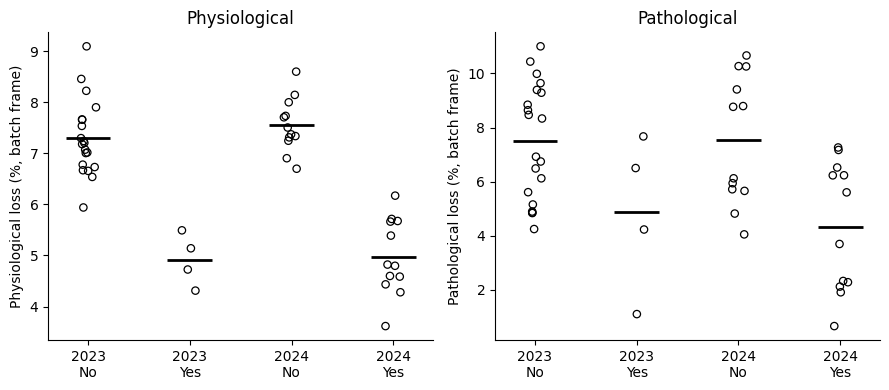

In [54]:
# Visualization of the clustering of data to support values above
    # Spread and center of both loss type per year x treatment
        # tested if the each arm is a single population before further testing
            # shows that it is for physiological and not for pathological loss

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

for ax, col, name in zip(axes,
                         ['loss_phys_batch_pct', 'loss_path_batch_pct'],
                         ['Physiological', 'Pathological']):
    groups = mango_batch.groupby(['year', 'hot_water_treated'])
    labels, positions = [], []
    for i, (key, sub) in enumerate(groups):
        y = sub[col].values
        x = np.full_like(y, i, dtype=float) + np.random.uniform(-.08, .08, len(y))
        ax.scatter(x, y, s=28, facecolors='none', edgecolors='black', linewidths=.9)
        ax.hlines(y.mean(), i - .22, i + .22, colors='black', linewidth=2)
        labels.append(f'{key[0]}\n{key[1]}')
        positions.append(i)
    ax.set_xticks(positions); ax.set_xticklabels(labels)
    ax.set_ylabel(f'{name} loss (%, batch frame)')
    ax.set_title(name)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

# Clusters for physiological loss is tighter than those for pathological loss

                               count   mean    std
year hot_water_treated season                     
2023 No                Dry        10  5.587  0.930
                       Wet        10  9.402  0.879
     Yes               Dry         2  2.666  2.211
                       Wet         2  7.086  0.827
2024 No                Dry         6  5.384  0.793
                       Wet         6  9.692  0.818
     Yes               Dry         6  2.165  0.971
                       Wet         6  6.504  0.629


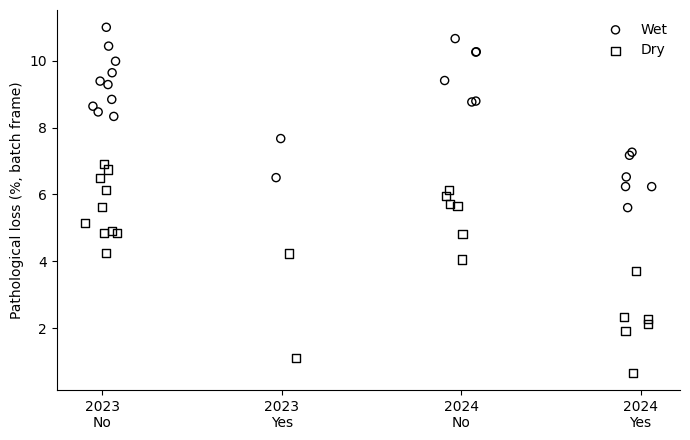

In [55]:
# Pre-step - arm-shape and Visualization of spread
    # Pathological loss data with an additional variable: season

fig, ax = plt.subplots(figsize=(7, 4.5))

groups = mango_batch.groupby(['year', 'hot_water_treated'])
markers = {'Wet': 'o', 'Dry': 's'}

for i, (key, sub) in enumerate(groups):
    for season, m in markers.items():
        s = sub[sub['season'] == season]
        y = s['loss_path_batch_pct'].values
        x = np.full_like(y, i, dtype=float) + np.random.uniform(-.10, .10, len(y))
        ax.scatter(x, y, s=34, marker=m, facecolors='none',
                   edgecolors='black', linewidths=1.0,
                   label=season if i == 0 else None)

ax.set_xticks(range(4))
ax.set_xticklabels([f'{k[0]}\n{k[1]}' for k, _ in groups])
ax.set_ylabel('Pathological loss (%, batch frame)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

print(mango_batch.groupby(['year', 'hot_water_treated', 'season'])['loss_path_batch_pct'].agg(['count', 'mean', 'std']).round(3))

In [56]:
# Confirming that season has no effect on physiological loss

print(mango_batch.groupby(['year', 'hot_water_treated', 'season'])['loss_phys_batch_pct'].agg(['count', 'mean', 'std']).round(3))

                               count   mean    std
year hot_water_treated season                     
2023 No                Dry        10  7.489  0.929
                       Wet        10  7.097  0.427
     Yes               Dry         2  4.902  0.835
                       Wet         2  4.933  0.294
2024 No                Dry         6  7.643  0.599
                       Wet         6  7.450  0.485
     Yes               Dry         6  4.945  0.713
                       Wet         6  5.013  0.839


# Pre-step c

# Hypothesis
    - Water loss and rot move together but weakly within a single group of batches
    - The 2023 -> 2024 increase survived the within-group check, given the increase in technology adoption

    - both predictions did not happen
        - the Pearson correlation below shows that there is no linear relationship within-group for the observed increase from 2023 to 2024
        - And water loss and rot did not show moving together within a group

In [57]:
# pooled — reproduce H09 §9
for y, sub in mango_batch.groupby('year'):
    r = sub['loss_phys_batch_pct'].corr(sub['loss_path_batch_pct'])
    print(f'{y} pooled  n={len(sub):2d}  r={r:.3f}')

print()
# within arms
for (y, arm), sub in mango_batch.groupby(['year', 'hot_water_treated']):
    r = sub['loss_phys_batch_pct'].corr(sub['loss_path_batch_pct'])
    print(f'{y} {arm:3s}     n={len(sub):2d}  r={r:.3f}')

2023 pooled  n=24  r=0.265
2024 pooled  n=24  r=0.495

2023 No      n=20  r=-0.205
2023 Yes     n= 4  r=0.501
2024 No      n=12  r=-0.031
2024 Yes     n=12  r=-0.084


# Hypothesis
- For physiological loss, those that are untreated is expected to loss more water weight as the use of HWT has been research to decrease water loss and shrivelling.
    - Ho (null hypothesis): Hot Water Treatment (HWT) has no effect on physiological loss
    - Ha (alternative hypothesis): Hot Water Treatment (HWT) has an effect on physiological loss
    - alpha = 0.05 
        - Decision rule p-value < alpha = 0.05 - statistically significant

# Result
    - untreated pct loss: 7.3-7.5
    - treated pct loss: 4.9 - 5.0
    - gap of 2.4
        - p = 1.08e-12 < alpha = 0.05 
            - reject Ho
    - 2023
        - p = 0.000269 < alpha = 0.05
            - reject Ho
    - 2024 
        - p = 5.19e-09 < alpha = 0.05
            - reject Ho

- p is computed ASSUMING Ho is true. p = 1.08e-12 means: if HWT did nothing, a gap this large between groups this size would arise by luck about once in a trillion. It is NOT the probability Ho is true.
- Two-sided test (scipy default): Ha is "has an effect", either direction. Negative t confirms treated < untreated.
- Statistical significance and practical size are separate claims. Both hold here: 2.4 pp on a 7.3 pp baseline is a third of water loss removed.

- Effect size did NOT change between years: 2.375 pp (2023) -> 2.567 pp (2024). 
    - The 0.19 pp difference is smaller than the within-arm SD (0.5-0.7). 
    - Adoption rose 4/24 -> 12/24; that changes how many batches benefit, not how much each benefits. 
    - "Treatment got more effective in 2024" is NOT supported.

In [58]:
# Significance testing of effect of treatment on physiological loss

treated   = mango_batch.loc[mango_batch['hot_water_treated'] == 'Yes', 'loss_phys_batch_pct']
untreated = mango_batch.loc[mango_batch['hot_water_treated'] == 'No', 'loss_phys_batch_pct']

t, p = sps.ttest_ind(treated, untreated, equal_var=False)
print(f'pooled   n={len(treated)}/{len(untreated)}  '
      f'gap={untreated.mean() - treated.mean():.3f} pp  t={t:.3f}  p={p:.3g}')

for y, sub in mango_batch.groupby('year'):
    a = sub.loc[sub['hot_water_treated'] == 'Yes',  'loss_phys_batch_pct']
    b = sub.loc[sub['hot_water_treated'] == 'No',   'loss_phys_batch_pct']
    t, p = sps.ttest_ind(a, b, equal_var=False)
    print(f'{y}     n={len(a)}/{len(b)}  '
          f'gap={b.mean() - a.mean():.3f} pp  t={t:.3f}  p={p:.3g}')

pooled   n=16/32  gap=2.424 pp  t=-11.760  p=1.08e-12
2023     n=4/20  gap=2.375 pp  t=-7.828  p=0.000269
2024     n=12/12  gap=2.567 pp  t=-9.744  p=5.19e-09


In [59]:
# Balance check — batch frame, per year
print(pd.crosstab([mango_batch['year'], mango_batch['hot_water_treated']], mango_batch['season']))

season                  Dry  Wet
year hot_water_treated          
2023 No                  10   10
     Yes                  2    2
2024 No                   6    6
     Yes                  6    6


In [60]:
# Four cells to be tested
cells = (mango_batch .groupby(['year', 'hot_water_treated', 'season'])['loss_path_batch_pct'].agg(['count', 'mean', 'std']))
print(cells.round(3))

                               count   mean    std
year hot_water_treated season                     
2023 No                Dry        10  5.587  0.930
                       Wet        10  9.402  0.879
     Yes               Dry         2  2.666  2.211
                       Wet         2  7.086  0.827
2024 No                Dry         6  5.384  0.793
                       Wet         6  9.692  0.818
     Yes               Dry         6  2.165  0.971
                       Wet         6  6.504  0.629


# Hypothesis
- The difference in mean pathological loss between wet-season and dry-season batches, after removing each treatment arm's mean (arm-blocked residuals), batch frame
    - Possible mechanism: presence of water during wet season results to more outbreak of anthracnose and stem end rot. This is because the weather is ideal for their growth and spread (water that drips from an infected fruit may infect other fruits, not only in the tree's but also during collection and other possible areas where the fruits may interact) 
- Ho: that difference = 0
- Ha: that difference != 0   (two-sided)
- alpha: 0.05
- Direction: two-sided. The mechanism makes dry > wet unlikely, not impossible, which is the bar for one-sided. Matches item 6.

# Result

- Reject Ho. Season affects pathological loss.
  - pooled  n=24/24  gap=4.119 pp  t=16.532  p=1.84e-20
  - 2023    n=12/12  gap=3.916 pp  t= 9.912  p=2.53e-09
  - 2024    n=12/12  gap=4.323 pp  t=13.683  p=5.35e-12
- Sign positive in all three: wet > dry, the predicted direction.
- Replicates independently by year. Pooled result is not carried by one year.

## Size, stated separately from significance
- 4.1 pp on a dry-season baseline of ~5.5 pp. Wet season roughly doubles rot.
- Larger than the treatment effect (~3.2 pp, batch frame). Season is the bigger driver of pathological loss in this dataset.

## Non-finding
- Season gap did not change between years. 3.916 -> 4.323 pp is 0.41 pp against  within-cell SDs of 0.63-0.97. Smaller than the noise.

## Cross-check
- Weighted season gap from the cell means reproduces the test:
  2023 (10*3.815 + 2*4.420)/12 = 3.916
  2024 (6*4.308 + 6*4.339)/12  = 4.323
  Blocking removed arm means without touching the season signal.

## What this does not license
- Season is not actionable. Value is baseline-setting, not intervention.
- Effects are additive: HWT removes the same ~3.2 pp in both seasons, so it clears a SMALLER FRACTION of wet-season rot. "HWT is more effective in wet season" is not supported -- the pp benefit is identical, the proportional benefit is lower.


In [61]:
# Significance testing of the effect of season on pathological loss
# Block on arm: remove each year x arm mean, leaving season + noise.
grp = mango_batch.groupby(['year', 'hot_water_treated'])['loss_path_batch_pct']
mango_batch['path_resid'] = mango_batch['loss_path_batch_pct'] - grp.transform('mean')

assert grp.transform('mean').notna().all()
assert abs(mango_batch.groupby(['year','hot_water_treated'])['path_resid'].mean()).max() < 1e-9

wet = mango_batch.loc[mango_batch['season'] == 'Wet', 'path_resid']
dry = mango_batch.loc[mango_batch['season'] == 'Dry', 'path_resid']
t, p = sps.ttest_ind(wet, dry, equal_var=False)
print(f'pooled   n={len(wet)}/{len(dry)}  gap={wet.mean()-dry.mean():.3f} pp  t={t:.3f}  p={p:.3g}')

for y, sub in mango_batch.groupby('year'):
    a = sub.loc[sub['season'] == 'Wet', 'path_resid']
    b = sub.loc[sub['season'] == 'Dry', 'path_resid']
    t, p = sps.ttest_ind(a, b, equal_var=False)
    print(f'{y}     n={len(a)}/{len(b)}  gap={a.mean()-b.mean():.3f} pp  t={t:.3f}  p={p:.3g}')

pooled   n=24/24  gap=4.119 pp  t=16.532  p=1.84e-20


2023     n=12/12  gap=3.916 pp  t=9.912  p=2.53e-09
2024     n=12/12  gap=4.323 pp  t=13.683  p=5.35e-12


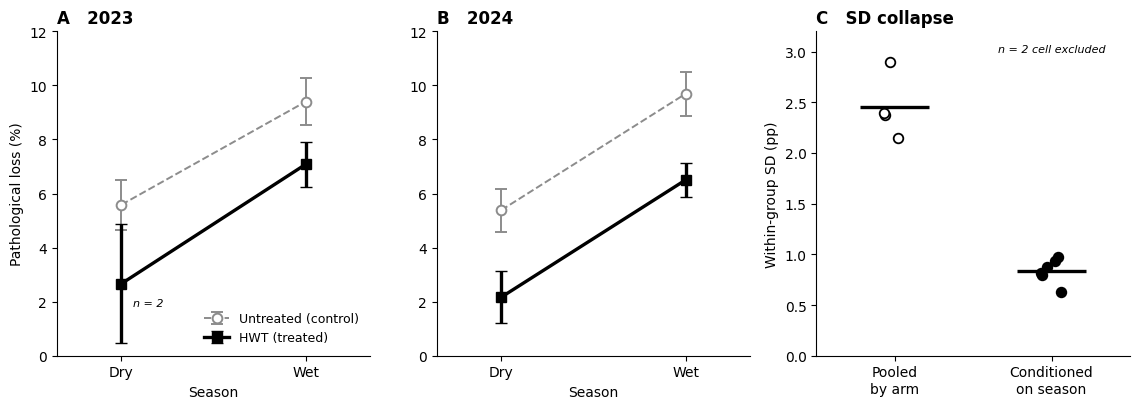

In [62]:
# Visualization on the significance testing of the effect of season on pathological loss
cells = (mango_batch
         .groupby(['year', 'hot_water_treated', 'season'])['loss_path_batch_pct']
         .agg(['count', 'mean', 'std']))

SEASONS = ['Dry', 'Wet']
x = np.arange(2)

style = {'No':  dict(color='0.55', marker='o', ls='--', lw=1.4, ms=7,
                     mfc='white', mec='0.55', mew=1.4, ecolor='0.55'),
         'Yes': dict(color='black', marker='s', ls='-', lw=2.4, ms=7,
                     mfc='black', mec='black', ecolor='black')}
label = {'No': 'Untreated (control)', 'Yes': 'HWT (treated)'}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2))

for ax, yr, tag in zip(axes[:2], [2023, 2024], ['A', 'B']):
    for arm in ['No', 'Yes']:
        m = [cells.loc[(yr, arm, s), 'mean'] for s in SEASONS]
        e = [cells.loc[(yr, arm, s), 'std'] for s in SEASONS]
        ax.errorbar(x, m, yerr=e, capsize=4,
                    label=label[arm] if tag == 'A' else None, **style[arm])
    ax.set_xticks(x); ax.set_xticklabels(SEASONS)
    ax.set_xlim(-0.35, 1.35); ax.set_ylim(0, 12)
    ax.set_title(f'{tag}   {yr}', loc='left', fontweight='bold')
    ax.set_xlabel('Season')
    if tag == 'A':
        ax.set_ylabel('Pathological loss (%)')
        ax.annotate('n = 2', xy=(0, cells.loc[(2023, 'Yes', 'Dry'), 'mean']),
                    xytext=(8, -16), textcoords='offset points', fontsize=8, style='italic')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

# Panel C -- the SD collapse
sd_pool = mango_batch.groupby(['year', 'hot_water_treated'])['loss_path_batch_pct'].std().values
sd_cond = cells.loc[cells['count'] > 2, 'std'].values      # n=2 cell excluded

ax = axes[2]
for i, (vals, lab) in enumerate([(sd_pool, 'Pooled\nby arm'), (sd_cond, 'Conditioned\non season')]):
    ax.scatter(np.full(len(vals), i) + np.random.default_rng(0).uniform(-.07, .07, len(vals)),
               vals, facecolor='white' if i == 0 else 'black',
               edgecolor='black', s=48, zorder=3, linewidths=1.3)
    ax.hlines(vals.mean(), i - .22, i + .22, color='black', lw=2.4, zorder=4)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pooled\nby arm', 'Conditioned\non season'])
ax.set_xlim(-.5, 1.5); ax.set_ylim(0, 3.2)
ax.set_ylabel('Within-group SD (pp)')
ax.set_title('C   SD collapse', loc='left', fontweight='bold')
ax.annotate('n = 2 cell excluded', xy=(1, 3.0), ha='center', fontsize=8, style='italic')
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

axes[0].legend(frameon=False, loc='lower right', fontsize=9)
fig.tight_layout()

fig.savefig('item7_season_path.svg', bbox_inches='tight')
fig.savefig('item7_season_path.tiff', dpi=600, bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

# Protocol-response within treated batches
-  Within 52–55 °C / 5–10 min, does higher temp or longer duration reduce loss further?
- Hot water treatment reduces pathological loss through the thermal inactivation of pathogens such as anthracnose and stem-end rot. The combination of optimal temperature and duration results to the inactivation of the pathogen population. The treatment however can also cause loss if not performed correctly. Loss due to fruit injury such as scalding, pitting, subcuticular browning.

# Hypothesis
- Ho: rho = 0
- Ha: rho != 0
- alpha = 0.05
    - Spearman primary, Pearson cross-check — at n = 16 one leverage point can swing r by 0.3, so disagreement between them names the point to inspect.

# Results
- p-values > alpha
    - Failed to reject Ho
        - both Spearman and Pearson data agree in sign and magnitude
        - ~50% power at n=16 — a moderate effect is not ruled out either
- Slope CIs: duration bounded (<1.5 pp across window). temp → path
  NOT bounded: CI spans -1.1 to +2.5 pp, 77% of the 3.2 pp treatment effect.
- Duration: run 5 min. Temperature: cannot conclude the low end saturates.

In [63]:
# Cross tabulation of hot water temperature with year
treated = mango_batch[mango_batch['hot_water_treated'] == 'Yes']
assert len(treated) == 16

treated.groupby(['hwt_temp_c', 'hwt_duration_min']).size()
pd.crosstab(treated['hwt_temp_c'], treated['year'])


year,2023,2024
hwt_temp_c,,
52.2,0,1
52.3,0,1
52.4,0,1
52.5,0,1
52.6,1,0
52.7,0,1
53.0,0,1
53.1,1,0
53.3,1,0


In [64]:
# Cross tabulation of hot water temperature and duration with season
pd.crosstab([treated['hwt_temp_c'], treated['hwt_duration_min']], treated['season'])

,season,Dry,Wet
hwt_temp_c,hwt_duration_min,,
52.2,5.0,0,1
52.3,7.0,0,1
52.4,9.0,1,0
52.5,8.0,1,0
52.6,7.0,1,0
52.7,6.0,0,1
53.0,6.0,1,0
53.1,6.0,0,1
53.3,8.0,1,0


In [65]:
# Spearman and Pearson statistical analysis on the effect of hot water bath temperature and duration of loss types part 1

treated = mango_batch[mango_batch['hot_water_treated'] == 'Yes'].copy()

loss_cols  = ['loss_phys_batch_pct', 'loss_path_batch_pct']
resid_cols = [c + '_r' for c in loss_cols]

for col in loss_cols:
    treated[col + '_r'] = treated[col] - treated.groupby('season')[col].transform('mean')

assert abs(treated.groupby('season')[resid_cols].mean()).max().max() < 1e-9

for y in resid_cols:
    for x in ['hwt_temp_c', 'hwt_duration_min']:
        rho, p   = sps.spearmanr(treated[x], treated[y])
        r,   p_p = sps.pearsonr(treated[x], treated[y])
        print(f'{x:18s} {y:24s} rho={rho:+.3f} p={p:.3f}   r={r:+.3f} p={p_p:.3f}')

hwt_temp_c         loss_phys_batch_pct_r    rho=-0.040 p=0.884   r=-0.049 p=0.856
hwt_duration_min   loss_phys_batch_pct_r    rho=+0.231 p=0.390   r=+0.177 p=0.512
hwt_temp_c         loss_path_batch_pct_r    rho=+0.287 p=0.281   r=+0.213 p=0.429
hwt_duration_min   loss_path_batch_pct_r    rho=+0.082 p=0.761   r=+0.026 p=0.923


In [66]:
# Spearman and Pearson statistical analysis on the effect of hot water bath temperature and duration of loss types part 2

for y in resid_cols:
    for x in ['hwt_temp_c', 'hwt_duration_min']:
        res = sps.linregress(treated[x], treated[y])
        half = res.stderr * sps.t.ppf(0.975, len(treated) - 2)
        print(f'{x:18s} {y:24s} slope={res.slope:+.3f} '
              f'CI=[{res.slope-half:+.3f}, {res.slope+half:+.3f}] pp/unit')

hwt_temp_c         loss_phys_batch_pct_r    slope=-0.041 CI=[-0.510, +0.429] pp/unit
hwt_duration_min   loss_phys_batch_pct_r    slope=+0.064 CI=[-0.139, +0.267] pp/unit
hwt_temp_c         loss_path_batch_pct_r    slope=+0.241 CI=[-0.394, +0.877] pp/unit
hwt_duration_min   loss_path_batch_pct_r    slope=+0.013 CI=[-0.272, +0.299] pp/unit


# Price and pathological loss association assessment
- Price and losses (more specifically pathological loss) move together in the dataset. What are the possible drivers which cause this association?  
    - One possible price driver is season
        - Wet season suppresses flowering and fruit set, which results to lower volume of harvest and price increase.
            - The season can also increase pathological losses

## Predictions 
    - price and pathological loss will show a relationship
        - There is a possibility that this relationship will be lost when season is added to the variable
    - Price will show no relationship with physiological loss

## Results
    - Price is highly affected by season, as it can drive the price due to the pathological losses in wet season for instance
    - Season can better predict pathological loss than price

In [67]:
# Welch t-test on the differences of the means
    # Checks if season affect both type of loss
PHYS = 'loss_phys_batch_pct'
PATH = 'loss_path_batch_pct'

def season_effect(df, outcome, label):
    dry = df.loc[df['season'] == 'Dry', outcome]
    wet = df.loc[df['season'] == 'Wet', outcome]
    t, p = sps.ttest_ind(dry, wet, equal_var=False)
    diff = wet.mean() - dry.mean()
    se   = np.sqrt(dry.var(ddof=1)/len(dry) + wet.var(ddof=1)/len(wet))
    dof  = (se**4) / (
        (dry.var(ddof=1)/len(dry))**2 / (len(dry)-1) +
        (wet.var(ddof=1)/len(wet))**2 / (len(wet)-1))
    half = se * sps.t.ppf(0.975, dof)
    print(f'{label:14s} {outcome:22s} n={len(dry)}/{len(wet)}  '
          f'wet-dry={diff:+.3f} pp  CI=[{diff-half:+.3f}, {diff+half:+.3f}]  p={p:.4f}')

for outcome in [PATH, PHYS]:
    season_effect(mango_batch, outcome, 'POOLED')
    for yr, g in mango_batch.groupby('year'):
        season_effect(g, outcome, f'  {yr}')

# In both years, wet season results to about 4% points for pathological loss with no apparent effect on shrinkage.

POOLED         loss_path_batch_pct    n=24/24  wet-dry=+4.119 pp  CI=[+3.128, +5.111]  p=0.0000
  2023         loss_path_batch_pct    n=12/12  wet-dry=+3.916 pp  CI=[+2.722, +5.110]  p=0.0000
  2024         loss_path_batch_pct    n=12/12  wet-dry=+4.323 pp  CI=[+2.762, +5.884]  p=0.0000
POOLED         loss_phys_batch_pct    n=24/24  wet-dry=-0.192 pp  CI=[-0.973, +0.588]  p=0.6220
  2023         loss_phys_batch_pct    n=12/12  wet-dry=-0.322 pp  CI=[-1.303, +0.659]  p=0.5011
  2024         loss_phys_batch_pct    n=12/12  wet-dry=-0.063 pp  CI=[-1.322, +1.197]  p=0.9188


In [68]:
# Constants
    # Defining the column names on one place

PRICE_ROW = 'price_php_per_kg'        # mango, varies by chain_node
PRICE     = 'price_pkh_php_per_kg'    # mango_batch, packinghouse only
PATH  = 'loss_path_batch_pct'
PHYS  = 'loss_phys_batch_pct'
BLOCK = ['year', 'season']

BENCH = {PATH: 4.119,   # season effect on pathological loss
         PHYS: 2.471}   # treatment effect on physiological loss 

In [69]:
# Frame guards
assert PRICE in mango_batch.columns
assert len(mango_batch) == 48
assert mango_batch['batch_id'].nunique() == 48
assert mango_batch[PRICE].notna().all()

In [70]:
# Node Structure
    # Checks if there is a price difference between packinghouse and transport
wide = mango.pivot_table(index='batch_id', columns='chain_node',
                         values=PRICE_ROW, aggfunc='first')
print(wide.columns.tolist())
print(wide.head(8))

nodes = wide.columns.tolist()
wide['diff']  = wide[nodes[1]] - wide[nodes[0]]
wide['ratio'] = wide[nodes[1]] / wide[nodes[0]]
print(wide[['diff', 'ratio']].describe())

meta = mango_batch.set_index('batch_id')[['year', 'season']]
print(wide.join(meta).groupby(['year', 'season'])[['diff', 'ratio']].mean())

# No meaningful difference

['packinghouse', 'transport']
chain_node  packinghouse  transport
batch_id                           
MB2023-001         75.64      75.33
MB2023-002         79.14      78.11
MB2023-003         67.15      66.66
MB2023-004         78.03      77.68
MB2023-005        133.28     134.12
MB2023-006        125.38     130.17
MB2023-007        131.05     131.58
MB2023-008        131.57     127.68
chain_node       diff      ratio
count       48.000000  48.000000
mean        -0.108333   0.999249
std          1.742933   0.016358
min         -3.890000   0.959963
25%         -1.090000   0.990087
50%         -0.255000   0.997458
75%          0.847500   1.009822
max          4.790000   1.038204
                 diff     ratio
year season                    
2023 Dry    -0.708333  0.990842
     Wet    -0.076667  0.999600
2024 Dry     0.667500  1.008637
     Wet    -0.315833  0.997919


In [71]:
# Structure Check
    # Sorted price by year, crosstabulation of price vs season and within season price spread

#  spread or clumps?
for yr, g in mango_batch.groupby('year'):
    print(yr, np.sort(g[PRICE].values))

# do the tiers align with season?
print(pd.crosstab([mango_batch['year'], mango_batch['season']],
                  pd.qcut(mango_batch[PRICE], 2, labels=['low', 'high'])))

#  within-cell variance — the estimability number
cell = (mango_batch.groupby(BLOCK)[PRICE]
        .agg(n='size', mean='mean', sd='std', lo='min', hi='max'))
cell['cv'] = cell['sd'] / cell['mean']
print(cell)

# Price is sorted into correct season. 
# With high prices in wet season and cheaper prices in dry season

2023 [ 67.15  72.12  72.61  73.08  73.75  74.02  74.85  75.64  76.43  78.03
  79.14  80.33 125.38 127.62 131.05 131.57 132.87 133.28 133.82 134.99
 135.97 136.25 137.4  139.55]
2024 [ 73.71  73.86  75.61  75.94  77.88  78.12  78.22  83.55  84.14  84.46
  84.6   87.3  131.33 131.36 134.02 136.51 137.99 138.46 141.21 142.76
 145.27 145.41 145.54 150.15]
price_pkh_php_per_kg  low  high
year season                    
2023 Dry               12     0
     Wet                0    12
2024 Dry               12     0
     Wet                0    12
              n        mean        sd      lo      hi        cv
year season                                                    
2023 Dry     12   74.762500  3.546674   67.15   80.33  0.047439
     Wet     12  133.312500  4.023319  125.38  139.55  0.030180
2024 Dry     12   79.782500  4.745645   73.71   87.30  0.059482
     Wet     12  140.000833  6.060359  131.33  150.15  0.043288


In [72]:
#  Marginal
    # Correlation between price and tye of loss
for y in [PATH, PHYS]:
    rho, p_s = sps.spearmanr(mango_batch[PRICE], mango_batch[y])
    r,   p_p = sps.pearsonr(mango_batch[PRICE], mango_batch[y])
    print(f'{y:24s} rho={rho:+.3f} p={p_s:.4f}   r={r:+.3f} p={p_p:.4f}')

# Strong link between price and pathological loss

loss_path_batch_pct      rho=+0.680 p=0.0000   r=+0.753 p=0.0000
loss_phys_batch_pct      rho=-0.031 p=0.8318   r=-0.074 p=0.6173


In [73]:
# Conditional
    # Removing season as a variable and look at the remaining relationships
    # Comparing batches only against other from the same season and year

resid = mango_batch.copy()
for c in [PRICE, PATH, PHYS]:
    resid[c + '_r'] = resid[c] - resid.groupby(BLOCK)[c].transform('mean')

rcols = [c + '_r' for c in [PRICE, PATH, PHYS]]
assert abs(resid.groupby(BLOCK)[rcols].mean()).max().max() < 1e-9

k  = resid.groupby(BLOCK).ngroups
df = len(resid) - k - 1

for y in [PATH, PHYS]:
    r, _ = sps.pearsonr(resid[PRICE + '_r'], resid[y + '_r'])
    t    = r * np.sqrt(df / (1 - r**2))
    print(f'{y:24s} partial r={r:+.3f}  df={df}  p={2*sps.t.sf(abs(t), df):.4f}')

span = resid[PRICE + '_r'].max() - resid[PRICE + '_r'].min()
for y in [PATH, PHYS]:
    res   = sps.linregress(resid[PRICE + '_r'], resid[y + '_r'])
    half  = res.stderr * sps.t.ppf(0.975, df)
    worst = max(abs(res.slope - half), abs(res.slope + half)) * span
    print(f'{y:24s} slope={res.slope:+.5f} '
          f'CI=[{res.slope-half:+.5f}, {res.slope+half:+.5f}] pp/PHP   '
          f'max across span={worst:.2f} pp ({worst/BENCH[y]*100:.0f}% of benchmark)')

# The relationship disappeared once season was accounted for.
    # which means the strong link relationship between price and pathological loss is due to season
    # The CI spans 64% and 94% of benchmark effect
        # We CANNOT claim that price has no effect, only that the observed relationship is due to season

loss_path_batch_pct      partial r=+0.103  df=43  p=0.5011
loss_phys_batch_pct      partial r=+0.143  df=43  p=0.3497
loss_path_batch_pct      slope=+0.03596 CI=[-0.06738, +0.13931] pp/PHP   max across span=2.62 pp (64% of benchmark)
loss_phys_batch_pct      slope=+0.04046 CI=[-0.04297, +0.12389] pp/PHP   max across span=2.33 pp (94% of benchmark)


In [74]:
# Correlation of price and season

sn = (mango_batch['season'] == 'Wet').astype(int)
print(sps.pearsonr(sn, mango_batch[PATH]))
print(sps.pearsonr(sn, mango_batch[PRICE]))

# season -> price = 0.98, season -> pathological loss = 0.78, price -> pathological loss = 0.75
# Season predicts pathological loss BETTER than price does. Price is season plus noise.

PearsonRResult(statistic=np.float64(0.7768437458806221), pvalue=np.float64(8.551575991848502e-11))
PearsonRResult(statistic=np.float64(0.9839955461369914), pvalue=np.float64(4.129403854794398e-36))


# Peso loss
- Losses are in percentage, can this be converted into peso honestly?

peso_loss = (loss_pct / 100) × starting_wt_kg × price_php_per_kg
- relationship of season with price: r = 0.984

## Predictions
- Treated batches is likely to carry a higher average price
    - the increase in adoption from 2023 to 2024
        - this prediction has been refuted as treatment is balance across season, the 60 pesos price gap cancels between groups
- Converting to peso will inflate the pathological loss type more than physiological loss type
    - Because it has been observed that in the wet season both price and pathological loss increases
- Year-over-year peso figure will not improve by much than the percentage figure
    - refuted as it shows more (-21.7% vs. -15.9%)
        - weight not price
- Weight is balance across treated and untreated groups

## Result
- For treatment: The peso figure is honest
    - treatment is balanced across season
    - mean price 107.5 pesos for treated and 106.7 pesos for untreated fruits
    - Pathological loss avoided is 1067 pesos while 866 for physiological loss, per batch
- For year-over-year: The peso figure is not honest
    - 0.8411 (loss fell) x 0.8930 (batches smaller) x 1.0563 (price rose)
        = 0.7934 predicted vs 0.7829 observed
- Price inflates the pathological loss type specifically
    - pathological 1.176x, physiological 0.957x against the independence
      benchmark
    - Pathological loss and price both increases with season
        - So the product varies more than chance

In [75]:
# Frame Guards
PRICE = 'price_pkh_php_per_kg'
PKH = 'packinghouse'
assert PRICE in mango_batch.columns
assert len(mango_batch) == 48
assert (mango_batch['hot_water_treated'] == 'Yes').sum() == 16

In [76]:
# Cell 3
# Peso loss per kg fruit entering the chain

PRICE = 'price_pkh_php_per_kg'

for pct in ['loss_phys_batch_pct', 'loss_path_batch_pct']:
    mango_batch[pct.replace('_pct', '_php_per_kg')] = (
        mango_batch[pct] / 100 * mango_batch[PRICE])

print(mango_batch[['loss_phys_batch_php_per_kg',
                   'loss_path_batch_php_per_kg']].describe().round(3))

       loss_phys_batch_php_per_kg  loss_path_batch_php_per_kg
count                      48.000                      48.000
mean                        7.009                       7.553
std                         2.377                       4.575
min                         3.131                       0.501
25%                         5.151                       3.797
50%                         6.421                       6.508
75%                         9.186                      11.578
max                        11.626                      15.115


In [77]:
# Cell 6
# Peso base
    # Add kg lost and starting weight, multiply by price
kg = (mango.groupby('batch_id')[['path_kg','phys_kg']].sum()
           .rename(columns={'path_kg':'path_kg_batch','phys_kg':'phys_kg_batch'}))

wt = (mango.loc[mango['chain_node']==PKH, ['batch_id','starting_wt_kg']]
           .drop_duplicates())
assert len(wt)==48 and wt['batch_id'].nunique()==48
assert wt['starting_wt_kg'].notna().all()

n_before = len(mango_batch)
mango_batch = (mango_batch
               .merge(kg, on='batch_id', how='left', validate='one_to_one')
               .merge(wt, on='batch_id', how='left', validate='one_to_one'))
assert len(mango_batch)==n_before==48
assert mango_batch[['path_kg_batch','phys_kg_batch','starting_wt_kg']].notna().all().all()

mango_batch['loss_path_php'] = mango_batch['path_kg_batch'] * mango_batch[PRICE]
mango_batch['loss_phys_php'] = mango_batch['phys_kg_batch'] * mango_batch[PRICE]

print(mango_batch.groupby('hot_water_treated')['starting_wt_kg']
                 .agg(['count','mean','std','min','max']).round(2))

                   count    mean    std    min    max
hot_water_treated                                    
No                    32  320.74  70.25  205.5  458.0
Yes                   16  313.48  68.44  231.3  445.2


In [78]:
# Cell 8
# Validating
      # Prove the batch percentage were built correctly

pkh_wt = (mango.loc[mango['chain_node']==PKH]
               .set_index('batch_id')['starting_wt_kg'])
kg_tot = mango.groupby('batch_id')[['path_kg','phys_kg']].sum()

implied = (kg_tot['path_kg'] / pkh_wt * 100).rename('kg_based')
cmp2 = mango_batch.set_index('batch_id')[['loss_path_batch_pct']].join(implied)
print('max |batch_pct - kg_based| =', round((cmp2['loss_path_batch_pct']-cmp2['kg_based']).abs().max(), 9))

imp_p = (kg_tot['phys_kg'] / pkh_wt * 100).rename('kg_based')
cmp3 = mango_batch.set_index('batch_id')[['loss_phys_batch_pct']].join(imp_p)
print('max |phys_pct  - kg_based| =', round((cmp3['loss_phys_batch_pct']-cmp3['kg_based']).abs().max(), 9))

# identity: the two peso routes must agree exactly
print('\nmax |php - php_per_kg*wt| =',
      round((mango_batch['loss_path_php']
             - mango_batch['loss_path_batch_php_per_kg']*mango_batch['starting_wt_kg']).abs().max(), 9))

max |batch_pct - kg_based| = 0.0
max |phys_pct  - kg_based| = 0.0

max |php - php_per_kg*wt| = 0.0


In [79]:
# Cell 9
# Confound Test
    # Dose price inflate the pathological loss type more than chance

cv = lambda s: s.std()/s.mean()

cvP = cv(mango_batch[PRICE])
print(f'CV(price) = {cvP:.4f}\n')

for arm in ['phys','path']:
    p = cv(mango_batch[f'loss_{arm}_batch_pct'])
    o = cv(mango_batch[f'loss_{arm}_batch_php_per_kg'])
    pred = np.sqrt(p**2 + cvP**2 + (p**2)*(cvP**2))
    print(f'{arm}: CV_pct={p:.4f}  CV_peso_obs={o:.4f}  CV_peso_indep={pred:.4f}  excess={o/pred:.3f}x')

# Pathological loss - 1.176x -- above 1 indicating that when there is a high loss of this type, the price for the same batch is also high. This is consistent with the wet season it the stressor for this price and loss increase 
# Physiological loss - 0.957x -- value is below 1 which indicates that physiological loss and price are independent

CV(price) = 0.2851

phys: CV_pct=0.2023  CV_peso_obs=0.3391  CV_peso_indep=0.3543  excess=0.957x
path: CV_pct=0.4124  CV_peso_obs=0.6057  CV_peso_indep=0.5150  excess=1.176x


In [80]:
# Cell 10
# Balance Check
    # Checks if treatment is evenly spread across seasons
print(pd.crosstab([mango_batch['year'], mango_batch['season']],
                  mango_batch['hot_water_treated'], margins=True)); print()
print(mango_batch.groupby('hot_water_treated')[PRICE].agg(['count','mean','std']).round(3))
r = mango_batch.groupby('hot_water_treated')[PRICE].mean()
print(f'\nP_treated / P_untreated = {r["Yes"]/r["No"]:.4f}   |   annihilation ~1.33')

# Treated samples - equal numbers for within year for season
    # Price comparison: untreated = 106.7 pesos vs treated = 107.5
    # 2023:
        # Dry = 2
        # Wet = 2
    # 2024
        # Dry = 6
        # Wet = 6

hot_water_treated  No  Yes  All
year season                    
2023 Dry           10    2   12
     Wet           10    2   12
2024 Dry            6    6   12
     Wet            6    6   12
All                32   16   48

                   count     mean     std
hot_water_treated                        
No                    32  106.713  30.825
Yes                   16  107.468  30.815

P_treated / P_untreated = 1.0071   |   annihilation ~1.33


In [81]:
# cell 11
# The Contrast
PCT = ['loss_phys_batch_pct','loss_path_batch_pct']
PHP = ['loss_phys_php','loss_path_php']

for cols, lab in [(PCT,'PERCENTAGE POINTS'), (PHP,'PESOS per batch')]:
    g = mango_batch.groupby('hot_water_treated')[cols].mean()
    print(lab); print(g.round(3))
    print('untreated - treated:'); print((g.loc['No']-g.loc['Yes']).round(3))
    print('relative reduction :'); print(((g.loc['No']-g.loc['Yes'])/g.loc['No']).round(4), '\n')

print('='*60)
for cols, lab in [(PCT,'PERCENTAGE POINTS'), (PHP,'PESOS per batch')]:
    g = mango_batch.groupby('year')[cols].mean()
    print(lab, '- year'); print(g.round(3))
    print('2024 - 2023:'); print((g.loc[2024]-g.loc[2023]).round(3))
    print('relative     :'); print(((g.loc[2024]-g.loc[2023])/g.loc[2023]).round(4), '\n')

print('='*60)
print(mango_batch.groupby(['year','hot_water_treated'])[PCT+PHP].agg(['mean','count']).round(2))

# Pathological loss reduction
    # percent loss: 40.49 % with pesos loss in percentage: 39.5% (1067.4 pesos)
# Physiological loss reduction
    # percent loss: 32.81 with pesos loss in percentage: 34.7% (865.6 pesos)
# Pesos per batch - year 
    # physiological:  -0.0920 (pct)   -0.1556 (peso)
    # pathological:   -0.1589 (pct)   -0.2171 (peso)

PERCENTAGE POINTS
                   loss_phys_batch_pct  loss_path_batch_pct
hot_water_treated                                          
No                               7.388                7.511
Yes                              4.964                4.470
untreated - treated:
loss_phys_batch_pct    2.424
loss_path_batch_pct    3.041
dtype: float64
relative reduction :
loss_phys_batch_pct    0.3281
loss_path_batch_pct    0.4049
dtype: float64 

PESOS per batch
                   loss_phys_php  loss_path_php
hot_water_treated                              
No                      2497.618       2701.700
Yes                     1631.979       1634.275
untreated - treated:
loss_phys_php     865.639
loss_path_php    1067.425
dtype: float64
relative reduction :
loss_phys_php    0.3466
loss_path_php    0.3951
dtype: float64 

PERCENTAGE POINTS - year
      loss_phys_batch_pct  loss_path_batch_pct
year                                          
2023                6.897                7.058
20

In [82]:
# Cell 12
# Decomposition
    # Splits the year change into three causes
print(mango_batch.groupby('year')[['starting_wt_kg', PRICE]]
                 .agg(['count','mean','std']).round(2)); print()

w = mango_batch.groupby('year')['starting_wt_kg'].mean()
p = mango_batch.groupby('year')[PRICE].mean()

print(f'weight 2024/2023 = {w[2024]/w[2023]:.4f}')
print(f'price  2024/2023 = {p[2024]/p[2023]:.4f}')

# From the cell above
    # Pathological loss pct: 2023 = 7.058, 2024 = 5.936, ratio = 0.8411
    # kg per batch: 2023 = 336.30, 2024 = 300.33, ratio = 0.8930
    # peso per kg: 2023 = 104.04, 2024 = 109.89, ratio = 1.0563
# pesos formula
    # pesos = loss%  ×  kg per batch  ×  ₱ per kg
    # 0.8411 × 0.8930 × 1.0563 = 0.7934
# Actual peso change from loss_path_php
    # 2320 = 2631.53, 2024 = 2060.26, ratio = 0.7829
# Values are close enough from each other. This means peso drop is explained by the three separate movements

     starting_wt_kg                price_pkh_php_per_kg               
              count    mean    std                count    mean    std
year                                                                  
2023             24  336.30  70.65                   24  104.04  30.13
2024             24  300.33  63.75                   24  109.89  31.21

weight 2024/2023 = 0.8930
price  2024/2023 = 1.0563


In [83]:
# Decomposition (computed)
g_pct = mango_batch.groupby('year')['loss_path_batch_pct'].mean()
g_php = mango_batch.groupby('year')['loss_path_php'].mean()

loss_ratio = g_pct[2024] / g_pct[2023]
obs_ratio  = g_php[2024] / g_php[2023]
w_ratio    = w[2024] / w[2023]
p_ratio    = p[2024] / p[2023]

print(f'loss %  ratio = {loss_ratio:.4f}')
print(f'weight  ratio = {w_ratio:.4f}')
print(f'price   ratio = {p_ratio:.4f}')
print(f'predicted     = {loss_ratio * w_ratio * p_ratio:.4f}')
print(f'observed      = {obs_ratio:.4f}')

loss %  ratio = 0.8411
weight  ratio = 0.8930
price   ratio = 1.0563
predicted     = 0.7934
observed      = 0.7829


In [84]:
# Exporting part 0
# Documented batch collapse — the deliverable of item 11.
# Reproduces the item-5 collapse exactly (verified to 0.0, part 2).

PKH = 'packinghouse'

BATCH_INVARIANT = ['batch_id', 'year', 'province_clean', 'season',
                   'cultivar', 'hot_water_treated', 'hwt_temp_c',
                   'hwt_duration_min']

def collapse_to_batch(rows):
    """One row per batch_id from the two-node row frame.

    DECISION 1 — node selection for batch-level scalars.
    price and starting_wt_kg are taken from the PACKINGHOUSE row.
    Packinghouse is chain ENTRY; its starting weight is the only single
    fixed base against which a whole-chain loss percentage is meaningful.
    Price is taken from the same node for consistency of reference point,
    not because the two nodes differ materially (verified: they do not).

    DECISION 2 — loss recombination is kg-based, never percentage-based.
        loss_*_batch_pct = SUM(kg lost, BOTH nodes) / pkh starting_wt_kg * 100
    Percentages do NOT add along the chain: the packinghouse row measures
    against entry weight, the transport row against what packinghouse handed
    over. Summing them overstates by the denominator shift (0.535 pp here);
    averaging them is meaningless (5.241 pp off). Absolute units add; divide
    once, at the end, by one fixed base. Batch % runs ~1.88x mean row %.

    DECISION 3 — weight columns are RETAINED.
    The item-5 collapse dropped them undocumented. Required by the balance
    procedure and by any peso figure. Not optional.

    Node-specific variables (chain_node, dwell_time_hrs, ambient_temp_c,
    ambient_rh_pct) are deliberately NOT carried to batch level. They vary
    within batch; collapsing them would invent a value never measured.
    """
    r = rows.copy()

    r['phys_kg'] = r['loss_physiological_pct'] / 100 * r['starting_wt_kg']
    r['path_kg'] = r['loss_pathological_pct']  / 100 * r['starting_wt_kg']

    inv = r.groupby('batch_id')[BATCH_INVARIANT[1:]].nunique(dropna=False)
    bad = inv[(inv > 1).any(axis=1)]
    assert bad.empty, f"batch-invariant column varies within batch:\n{bad}"

    base = r[r['chain_node'] == PKH].set_index('batch_id')
    kg   = r.groupby('batch_id')[['phys_kg', 'path_kg']].sum()

    b = base[BATCH_INVARIANT[1:]].copy()
    b['starting_wt_kg']            = base['starting_wt_kg']
    b['price_packinghouse_php_kg'] = base['price_php_per_kg']
    b['phys_kg_batch']             = kg['phys_kg']
    b['path_kg_batch']             = kg['path_kg']
    b['loss_phys_batch_pct'] = kg['phys_kg'] / base['starting_wt_kg'] * 100
    b['loss_path_batch_pct'] = kg['path_kg'] / base['starting_wt_kg'] * 100
    b['loss_phys_php'] = b['phys_kg_batch'] * b['price_packinghouse_php_kg']
    b['loss_path_php'] = b['path_kg_batch'] * b['price_packinghouse_php_kg']

    return b.reset_index()

In [85]:
# Exporting part 1

mango_batch_v2 = collapse_to_batch(mango)

print(mango_batch_v2.shape)                    # expect (48, 16)
print(mango_batch_v2.columns.tolist())

(48, 16)
['batch_id', 'year', 'province_clean', 'season', 'cultivar', 'hot_water_treated', 'hwt_temp_c', 'hwt_duration_min', 'starting_wt_kg', 'price_packinghouse_php_kg', 'phys_kg_batch', 'path_kg_batch', 'loss_phys_batch_pct', 'loss_path_batch_pct', 'loss_phys_php', 'loss_path_php']


In [86]:
# Exporting part 2 
# Reconciliation

chk = (mango_batch.set_index('batch_id')[['loss_phys_batch_pct','loss_path_batch_pct']]
       .join(mango_batch_v2.set_index('batch_id')[['loss_phys_batch_pct','loss_path_batch_pct']],
             lsuffix='_old', rsuffix='_new'))

print('phys max |old-new| =', (chk['loss_phys_batch_pct_old'] - chk['loss_phys_batch_pct_new']).abs().max())
print('path max |old-new| =', (chk['loss_path_batch_pct_old'] - chk['loss_path_batch_pct_new']).abs().max())

w_old = mango_batch.set_index('batch_id')['starting_wt_kg']
w_new = mango_batch_v2.set_index('batch_id')['starting_wt_kg']
p_old = mango_batch.set_index('batch_id')['price_pkh_php_per_kg']
p_new = mango_batch_v2.set_index('batch_id')['price_packinghouse_php_kg']
print('wt    max |old-new| =', (w_old - w_new).abs().max())
print('price max |old-new| =', (p_old - p_new).abs().max())

assert len(mango_batch_v2) == 48
assert mango_batch_v2.groupby('hot_water_treated').size().to_dict() == {'No':32, 'Yes':16}
assert pd.crosstab([mango_batch_v2['year'], mango_batch_v2['season']],
                   mango_batch_v2['hot_water_treated']).values.tolist() == [[10,2],[10,2],[6,6],[6,6]]
print('guards passed')

phys max |old-new| = 0.0
path max |old-new| = 0.0
wt    max |old-new| = 0.0
price max |old-new| = 0.0
guards passed


In [87]:
# Exporting part 3
# The Rh pass
del obs                                   # stale, 96 rows, selected nothing

obs_true = mango[~mango['rh_estimated']]
print('observed-only rows:', len(obs_true), '(expect 91)')

for col in ['dwell_time_hrs','ambient_temp_c','ambient_rh_pct']:
    print(f'\n--- {col} ---')
    print(obs_true.groupby('year')[[col,'loss_physiological_pct',
                                    'loss_pathological_pct']].corr().round(3))


observed-only rows: 91 (expect 91)

--- dwell_time_hrs ---
                             dwell_time_hrs  loss_physiological_pct  \
year                                                                  
2023 dwell_time_hrs                   1.000                   0.119   
     loss_physiological_pct           0.119                   1.000   
     loss_pathological_pct            0.211                   0.268   
2024 dwell_time_hrs                   1.000                  -0.310   
     loss_physiological_pct          -0.310                   1.000   
     loss_pathological_pct           -0.380                   0.533   

                             loss_pathological_pct  
year                                                
2023 dwell_time_hrs                          0.211  
     loss_physiological_pct                  0.268  
     loss_pathological_pct                   1.000  
2024 dwell_time_hrs                         -0.380  
     loss_physiological_pct                  0.533  
 

In [88]:
# Exporting part 4
# Balance Table
def balance(frame, contrast_col, tol=0.05):
    """Group-mean weight and price by a contrast variable.

    A peso figure is honest when weight AND price are balanced across the
    SPECIFIC comparison drawn. Balance is a property of the comparison, not
    of the dataset: the same 48 batches pass on treatment and fail on year.
    tol = 5% on both ratios, taken against the first group as reference.
    """
    g = (frame.groupby(contrast_col)
              .agg(n=('batch_id','size'),
                   mean_wt_kg=('starting_wt_kg','mean'),
                   mean_price_php_kg=('price_packinghouse_php_kg','mean'))
              .reset_index())
    ref = g.iloc[0]
    g['wt_ratio']    = (g['mean_wt_kg']        / ref['mean_wt_kg']).round(4)
    g['price_ratio'] = (g['mean_price_php_kg'] / ref['mean_price_php_kg']).round(4)
    ok = bool(((g['wt_ratio']-1).abs().max() < tol) and
              ((g['price_ratio']-1).abs().max() < tol))
    g.insert(0, 'contrast', contrast_col)
    g = g.rename(columns={contrast_col: 'group'})
    g['group'] = g['group'].astype(str)
    g['peso_licensed'] = ok
    g['guidance'] = ('Peso figures are reportable for this contrast.' if ok else
                     'DO NOT report peso figures across this contrast. Weight '
                     'and/or price are unbalanced; a peso change mixes market '
                     'movement with postharvest effect. Report percentage points.')
    return g

mango_balance = pd.concat([balance(mango_batch_v2, 'hot_water_treated'),
                           balance(mango_batch_v2, 'year'),
                           balance(mango_batch_v2, 'season')],
                          ignore_index=True)
print(mango_balance.round(3).to_string(index=False))

         contrast group  n  mean_wt_kg  mean_price_php_kg  wt_ratio  price_ratio  peso_licensed                                                                                                                                                                    guidance
hot_water_treated    No 32     320.738            106.713     1.000        1.000           True                                                                                                                              Peso figures are reportable for this contrast.
hot_water_treated   Yes 16     313.475            107.468     0.977        1.007           True                                                                                                                              Peso figures are reportable for this contrast.
             year  2023 24     336.304            104.038     1.000        1.000          False DO NOT report peso figures across this contrast. Weight and/or price are unbalanced; a peso change m

In [89]:
# Exporting part 5
# Write the four tables

from pathlib import Path
OUT = Path('export'); OUT.mkdir(exist_ok=True)

# rows: keep wt_corrected and rh_estimated -- provenance flags for the 3 repaired
# weights and 5 imputed RH values. Without them, repaired data is indistinguishable
# from measured data downstream.
rows_out  = mango.drop(columns=['month'], errors='ignore').copy()
batch_out = mango_batch_v2.copy()

dictionary = pd.DataFrame([
 ('mango_batch','loss_path_batch_pct',
  'Whole-chain pathological loss (rot), percent of packinghouse entry weight. '
  'DEFINITION: sum of kg lost across BOTH chain nodes / packinghouse starting_wt_kg '
  'x 100. NOT the sum of the two node percentages (off by 0.535 pp) and NOT their '
  'mean (off by 5.241 pp). Kilograms add along a chain; percentages do not, because '
  'each node measures against a different denominator.'),
 ('mango_batch','loss_phys_batch_pct',
  'Same definition, physiological (water) loss.'),
 ('mango_batch','starting_wt_kg',
  'Packinghouse entry weight, the single fixed base for all batch percentages. '
  'Required for the balance check. Fell 10.7% from 2023 to 2024; the data cannot '
  'say why. Do not drop.'),
 ('mango_batch','price_packinghouse_php_kg',
  'Price at the packinghouse node. Market-set before harvest and driven by season '
  '(r = 0.98). NOT causally linked to loss: the marginal price-rot correlation of '
  '+0.75 collapses to zero once season is partialled out. Required for the balance check.'),
 ('mango_batch','loss_path_php',
  'Peso value of rot = path_kg_batch x price. CONDITIONAL COLUMN: valid only for '
  'contrasts where mango_balance.peso_licensed is TRUE. Across years it returns '
  '-21.7%, of which only -15.9% is postharvest; the rest is a 10.7% fall in batch '
  'weight and a 5.6% rise in price. Across season it is worse. See mango_balance first.'),
 ('mango_batch','loss_phys_php',
  'Same conditional status as loss_path_php.'),
 ('mango_batch','hwt_temp_c',
  'STRUCTURAL NA when hot_water_treated = No. Untreated batches had no protocol '
  'applied; the blank is a fact, not missing data. Do not impute or filter on it. '
  'No dose-response detected within the 52-55 C / 5-10 min window.'),
 ('mango_batch','hwt_duration_min',
  'Structural NA, as hwt_temp_c.'),
 ('mango_balance','peso_licensed',
  'TRUE if mean weight and mean price are within 5% across the groups of this '
  'contrast. Check this before using any _php column on that axis. '
  'hot_water_treated passes; year and season both fail.'),
 ('mango_balance','price_ratio',
  'Group mean price divided by the reference group mean. season = 1.768 (wet-season '
  'fruit costs 76.8% more than dry). That is 35x the treatment contrast gap and past '
  'the ~1.33 annihilation threshold. A peso figure split by season multiplies the '
  'season price effect by the season rot effect and reproduces the spurious '
  'price-rot association of item 9.'),
 ('mango_rows','chain_node',
  'packinghouse or transport. Two rows per batch_id. Rows within a batch are NOT '
  'independent: treatment is assigned per batch. True n = 48 batches, not 96 rows. '
  'Do not run hypothesis tests on this table.'),
 ('mango_rows','wt_corrected',
  'TRUE for 3 rows whose ending_wt_kg exceeded starting_wt_kg and was reconstructed '
  'from the loss columns (MB2023-007, MB2023-015, MB2024-011, packinghouse node).'),
 ('mango_rows','rh_estimated',
  'TRUE for 5 rows whose ambient_rh_pct was filled with the column median (78.9). '
  'The null-variable result was re-verified on the 91 measured rows only and held: '
  'RH r = +0.12 to +0.21 against both loss types, dwell time reverses sign between '
  'years (+0.21 to -0.38), ambient temp r = -0.19 to -0.27. None approach the '
  '4.119 pp season or 2.471 pp treatment benchmarks.'),
], columns=['table','column','definition'])

rows_out.to_csv(OUT/'mango_rows.csv', index=False)
batch_out.to_csv(OUT/'mango_batch.csv', index=False)
mango_balance.to_csv(OUT/'mango_balance.csv', index=False)
dictionary.to_csv(OUT/'mango_dictionary.csv', index=False)

for f in sorted(OUT.glob('*.csv')):
    print(f'{f.name:24} {pd.read_csv(f).shape}')

mango_balance.csv        (6, 9)
mango_batch.csv          (48, 16)
mango_dictionary.csv     (13, 3)
mango_rows.csv           (96, 23)


In [90]:
# Exporting part 6
# Round-trip verification -- read the files back, verify from disk only

rb = pd.read_csv(OUT/'mango_batch.csv')
rr = pd.read_csv(OUT/'mango_rows.csv')
rl = pd.read_csv(OUT/'mango_balance.csv')
rd = pd.read_csv(OUT/'mango_dictionary.csv')

# structure
assert len(rb) == 48 and rb['batch_id'].nunique() == 48
assert len(rr) == 96 and rr['batch_id'].nunique() == 48
assert rb.groupby('hot_water_treated').size().to_dict() == {'No':32, 'Yes':16}

# structural NA must survive the round trip -- 32 untreated batches, no protocol
assert rb['hwt_temp_c'].isna().sum() == 32
assert rb['hwt_duration_min'].isna().sum() == 32
assert rb.loc[rb['hot_water_treated']=='Yes', 'hwt_temp_c'].notna().all()

# provenance flags
assert rr['wt_corrected'].sum() == 3
assert rr['rh_estimated'].sum() == 5

# balance table reaches all three contrasts
assert set(rl['contrast']) == {'hot_water_treated','year','season'}
print(rl[['contrast','group','wt_ratio','price_ratio','peso_licensed']].to_string(index=False))

# headline figures must regenerate from the exported file ALONE
g = rb.groupby('hot_water_treated')[['loss_phys_batch_pct','loss_path_batch_pct']].mean()
gap = (g.loc['No'] - g.loc['Yes']).round(3)
print('\ntreatment gap pp :', gap.to_dict())            # expect 2.424 / 3.041

y = rb.groupby('year')['loss_path_batch_pct'].mean()
print('path year change :', round(y[2024]/y[2023] - 1, 4))   # expect -0.1589

t = rb.loc[rb['hot_water_treated']=='Yes', 'loss_phys_batch_pct']
u = rb.loc[rb['hot_water_treated']=='No',  'loss_phys_batch_pct']
print('phys t-test p    :', f'{sps.ttest_ind(t, u, equal_var=False)[1]:.3g}')  # expect 1.08e-12

print('\nround trip clean')

         contrast group  wt_ratio  price_ratio  peso_licensed
hot_water_treated    No    1.0000       1.0000           True
hot_water_treated   Yes    0.9774       1.0071           True
             year  2023    1.0000       1.0000          False
             year  2024    0.8930       1.0563          False
           season   Dry    1.0000       1.0000          False
           season   Wet    0.9526       1.7685          False

treatment gap pp : {'loss_phys_batch_pct': 2.424, 'loss_path_batch_pct': 3.041}
path year change : -0.1589
phys t-test p    : 1.08e-12

round trip clean
